# 03. 교통약자 사고이력 분석

In [ ]:
import geopandas as gpd
import pandas as pd
import folium
import json
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os
import seaborn as sns
from folium.plugins import HeatMap
from shapely.geometry import Point
from geoband.API import *

## 1) 데이터 불러오기

In [87]:
lup1 = gpd.read_file("22._토지이용계획도_(4개_신도시).geojson")

# 종속변수; Dependent Variable
dv = gpd.read_file("13._교통사고이력.geojson")

## 2) 4개 신도시 사고 데이터 추출


In [ ]:
# lup1데이터만 분석대상지역(동탄 1·2 신도시, 위례 신도시, 하남미사, 판교신도시)이므로 


#  iv_peo2를 GeoDataFrame으로 변환 (위경도 좌표계 EPSG:4326 설정)
dv_gdf = gpd.GeoDataFrame(dv,  crs="EPSG:4326")

dv = gpd.sjoin(dv_gdf, lup1, how='inner', predicate='within')

dv = dv.drop(columns=['index_right'])
dv['zoneName']=dv['zoneName'].map({'성남판교지구 택지개발사업':'판교신도시',\
                                                 '위례 택지개발사업 예정지구':'위례신도시', \
                                                 '하남미사 공공주택지구 조성사업': '하남미사',\
                                                 '화성동탄지구 택지개발사업':'동탄신도시', '화성동탄2 택지개발사업':'동탄신도시'})

## 3) 교통약자 그룹 분리

In [98]:
dv_child=dv[(dv['age_group']=='12세 이하')]
dv_old=dv[(dv['age_group']=='65세 이상')|(dv['age_group']=='61-64세')]

In [ ]:
fe = fm.FontEntry(
    fname=r'./NanumGothic.ttf', # ttf 파일이 저장되어 있는 경로
    name='NanumGothic')                        # 이 폰트의 원하는 이름 설정
fm.fontManager.ttflist.insert(0, fe)              # Matplotlib에 폰트 추가
plt.rcParams.update({'font.size': 18, 'font.family': 'NanumGothic'})

## 4) 피해 차량 유형 비교

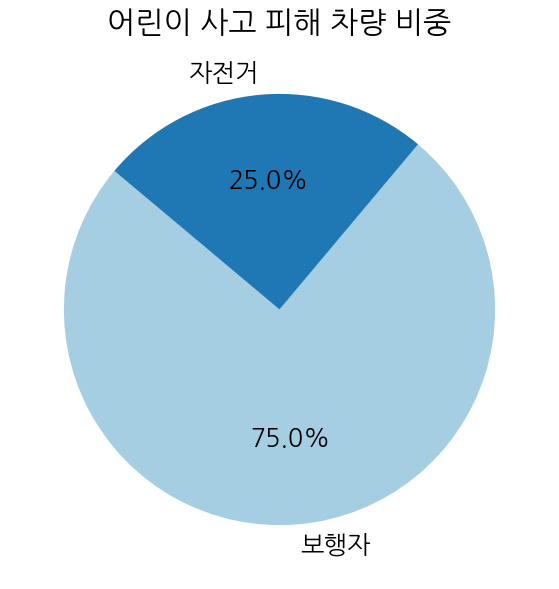

In [ ]:
data_counts = dv_child['victim_vhcle'].value_counts()

plt.figure(figsize=(10, 7))
plt.pie(data_counts, 
        labels=data_counts.index, 
        autopct='%1.1f%%',     
        startangle=140,        
        colors=plt.cm.Paired.colors)

plt.title('어린이 사고 피해 차량 비중')
plt.show()

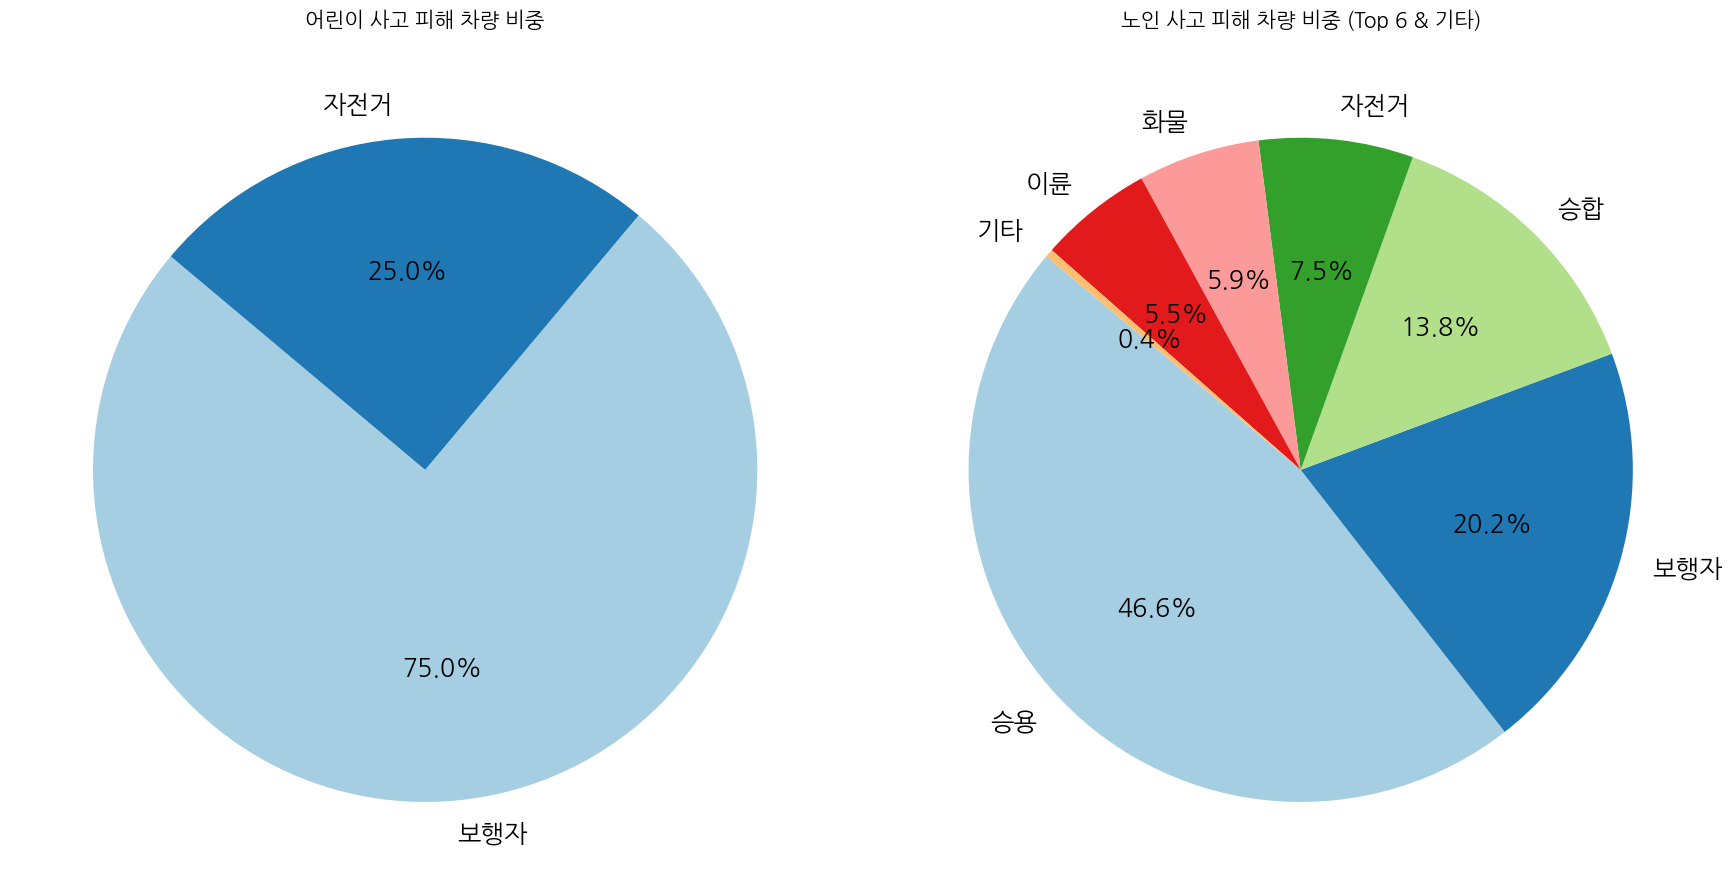

In [ ]:
# 1. 데이터 준비 함수 (상위 6개 + 기타 합치기)
def get_plot_data(df):
    counts = df['victim_vhcle'].value_counts()
    top6 = counts.head(6)
    etc_sum = counts.iloc[6:].sum()
    if etc_sum > 0:
        plot_data = top6.copy()
        plot_data['기타'] = etc_sum
        return plot_data
    return counts

child_plot = get_plot_data(dv_child)
old_plot = get_plot_data(dv_old)

fig, ax = plt.subplots(1, 2, figsize=(18, 9))
colors = plt.cm.Paired.colors

ax[0].pie(child_plot, 
          labels=child_plot.index, 
          autopct='%1.1f%%', 
          startangle=140, 
          colors=colors)
ax[0].set_title('어린이 사고 피해 차량 비중', fontsize=15, pad=20)

ax[1].pie(old_plot, 
          labels=old_plot.index, 
          autopct='%1.1f%%', 
          startangle=140, 
          colors=colors)
ax[1].set_title('노인 사고 피해 차량 비중 (Top 6 & 기타)', fontsize=15, pad=20)

plt.tight_layout()
plt.show()


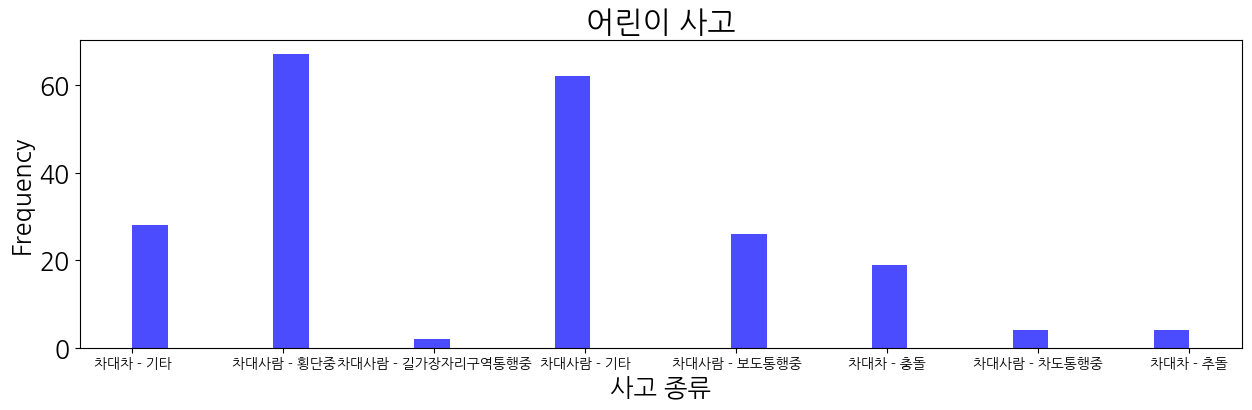

In [ ]:
plt.rc('font', family='NanumGothic') 

plt.figure(figsize=(15, 4))

plt.hist(dv_child['acc_type'], bins=30, color='blue', alpha=0.7)
plt.xticks(fontsize=10)
plt.title('어린이 사고')
plt.xlabel('사고 종류')
plt.ylabel('Frequency')
plt.show()

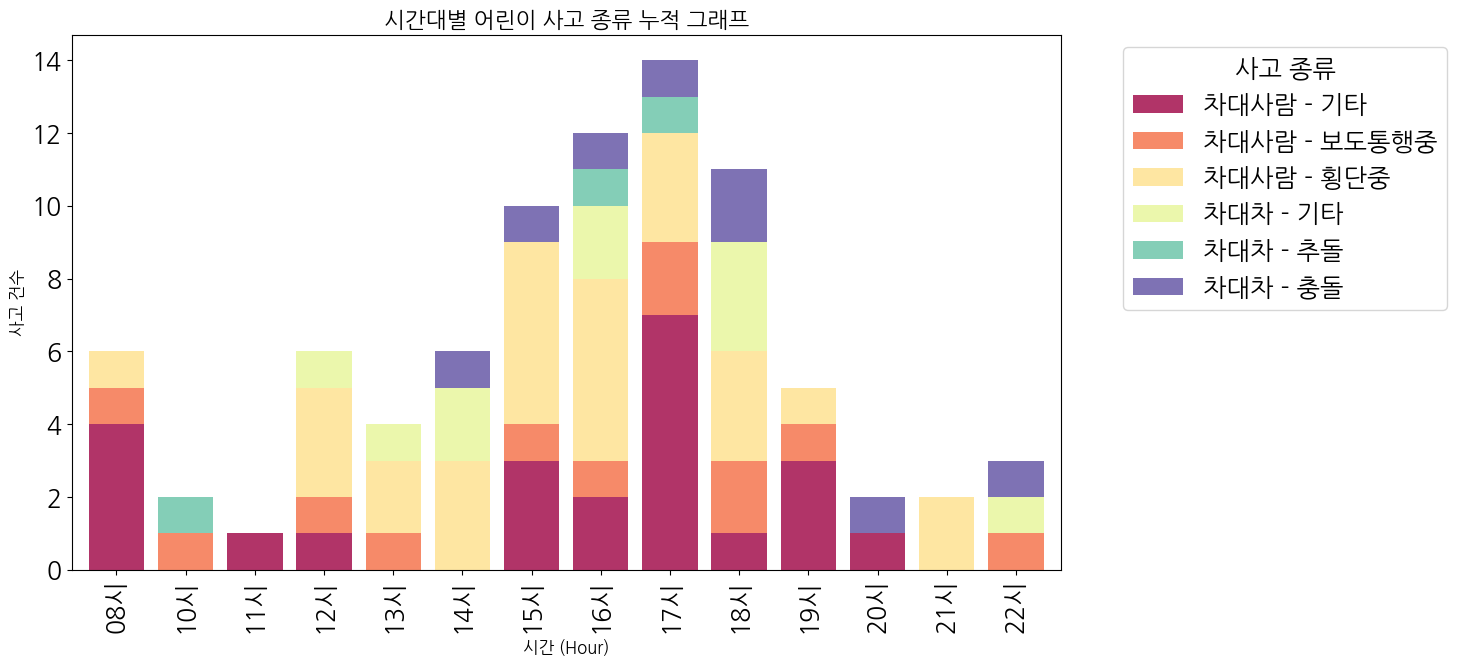

In [ ]:
stacked_data = pd.crosstab(dv_child['acc_time'], dv_child['acc_type'])

stacked_data.plot(kind='bar', stacked=True, figsize=(15, 7), 
                  width=0.8, alpha=0.8, colormap='Spectral')

plt.title('시간대별 어린이 사고 종류 누적 그래프', fontsize=16)
plt.xlabel('시간 (Hour)', fontsize=12)
plt.ylabel('사고 건수', fontsize=12)
plt.legend(title='사고 종류', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


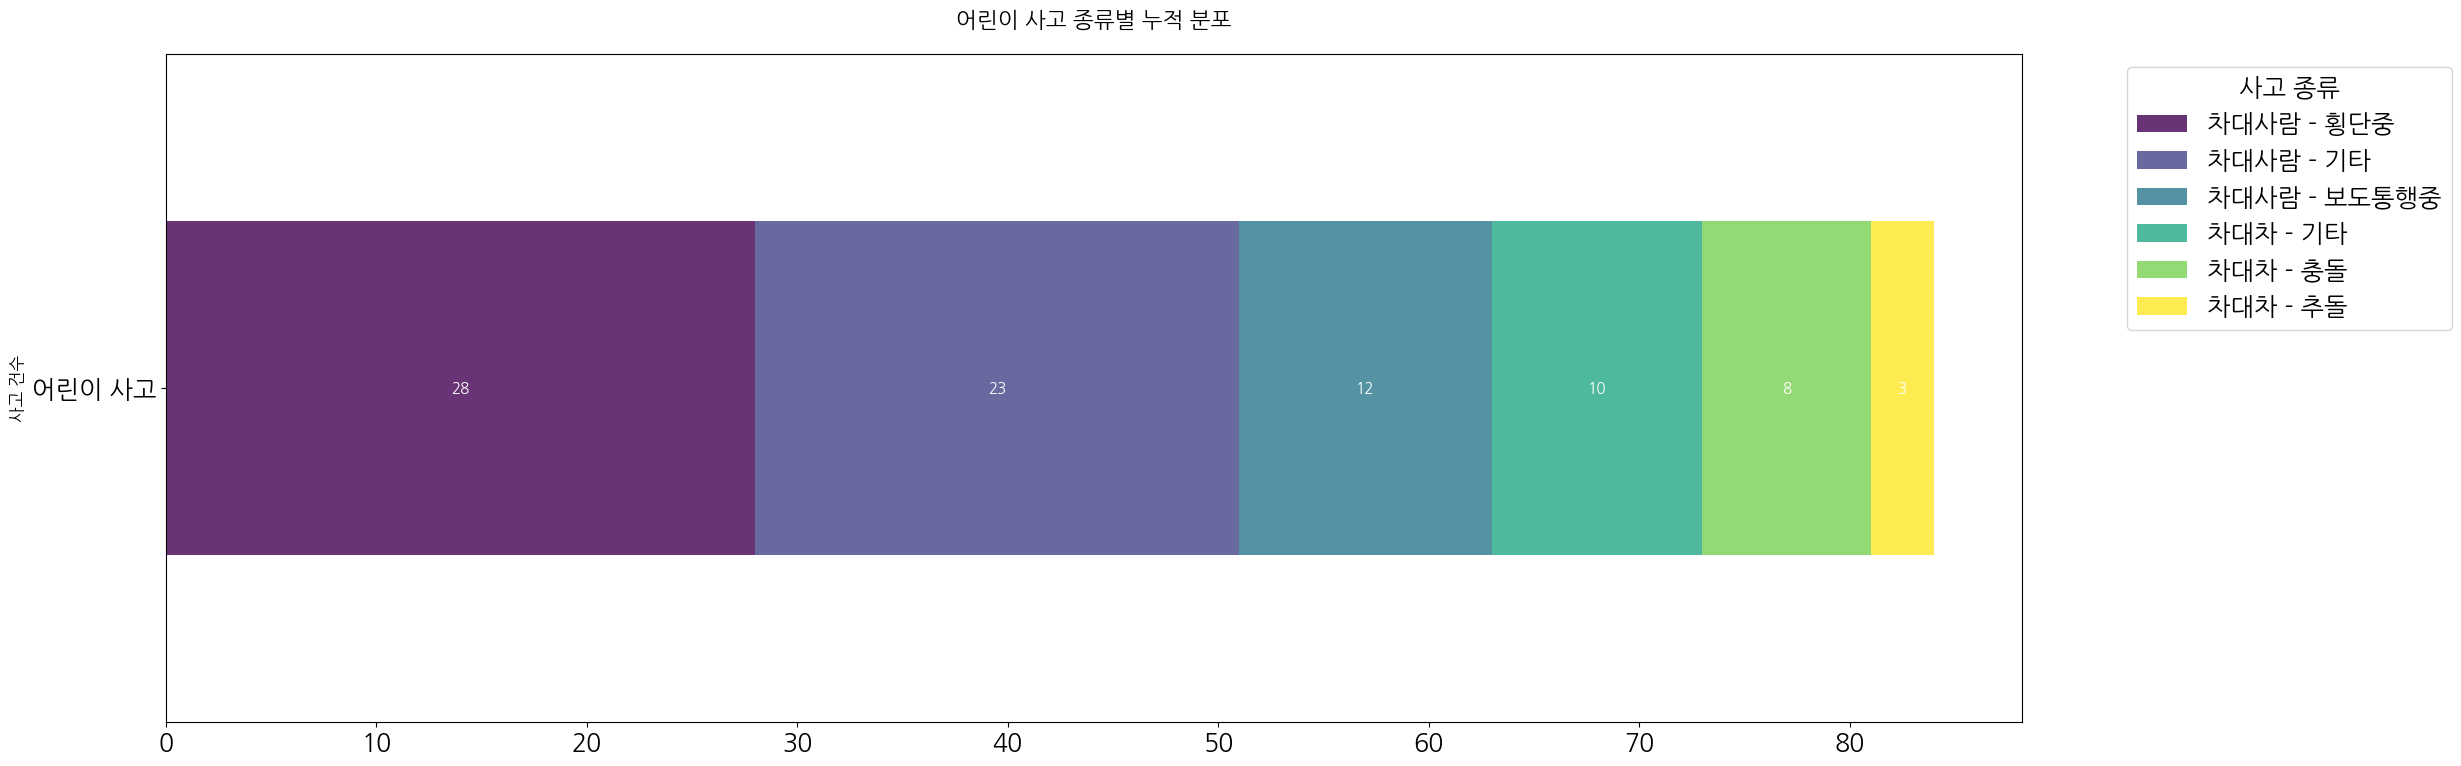

In [ ]:
plt.rc('font', family='NanumGothic')

acc_counts = dv_child['acc_type'].value_counts().to_frame().T
acc_counts.index = ['어린이 사고']

ax = acc_counts.plot(kind='barh', stacked=True, figsize=(25,8), 
                     colormap='viridis', alpha=0.8, width=0.5)

plt.title('어린이 사고 종류별 누적 분포', fontsize=16, pad=20)
plt.ylabel('사고 건수', fontsize=12)
plt.xticks(rotation=0) 

plt.legend(title='사고 종류', bbox_to_anchor=(1.05, 1), loc='upper left')

for p in ax.patches:
    width = p.get_width()   
    height = p.get_height()
    x, y = p.get_xy()      
    if width > 0:
        ax.text(x + width/2,        
                y + height/2,        
                f'{int(width)}',    
                ha='center', va='center', 
                fontsize=11, color='white', fontweight='bold')
plt.tight_layout()
plt.show()

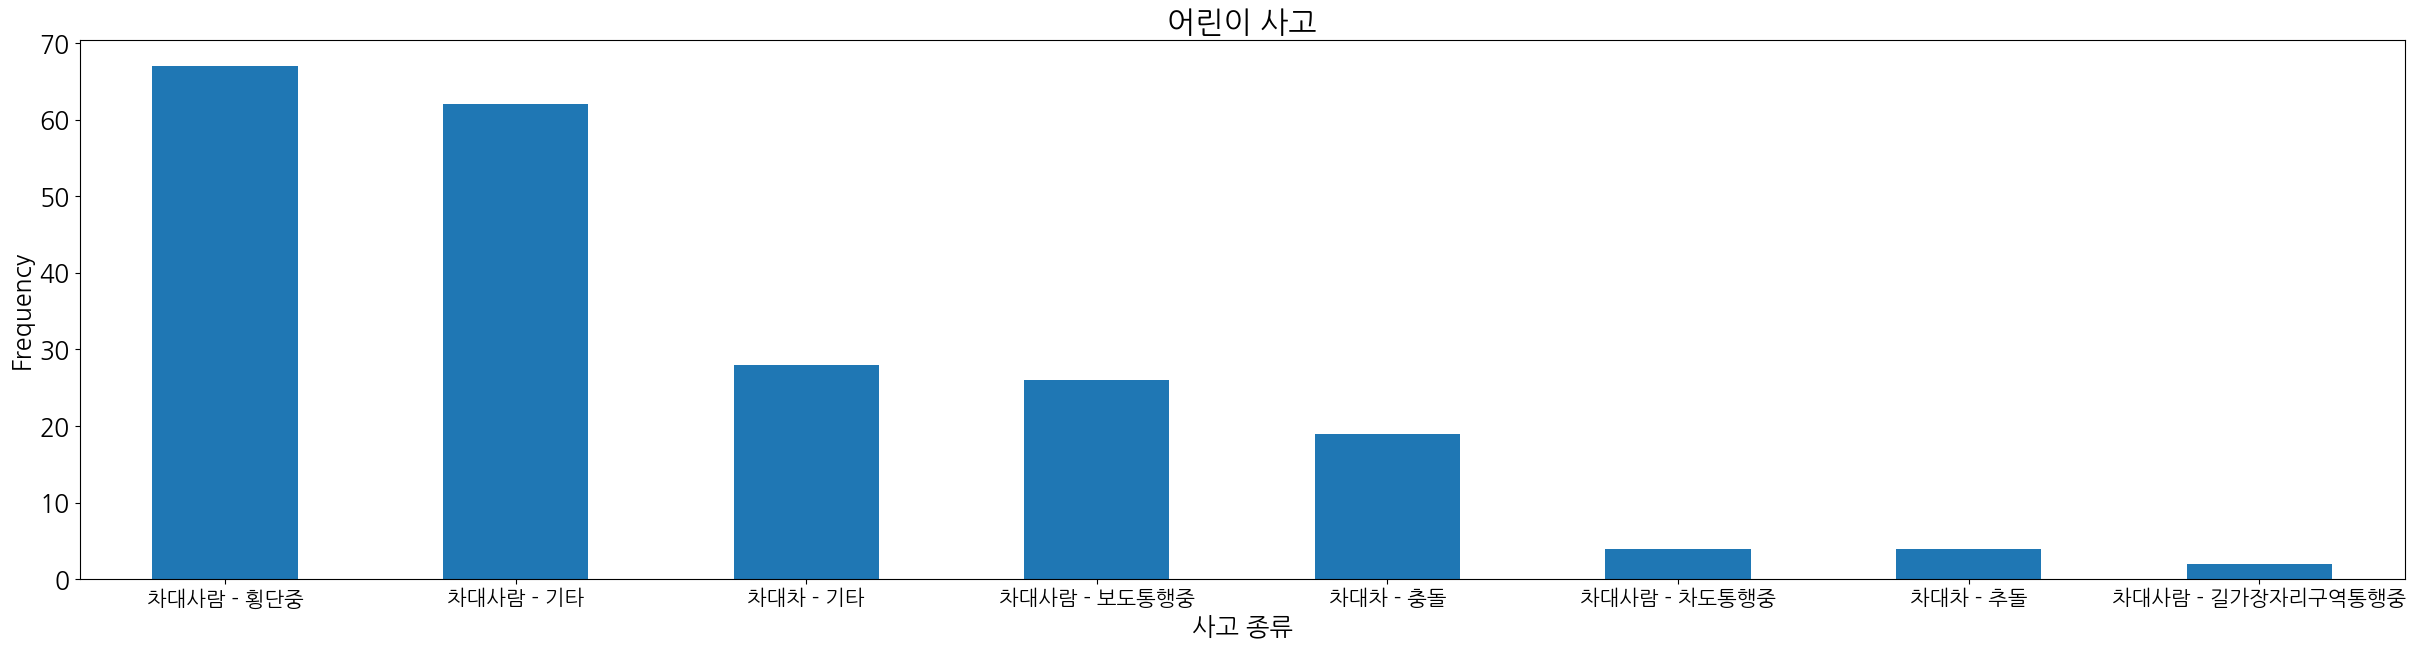

In [ ]:
plt.rc('font', family='NanumGothic') 

counts = dv_child['acc_type'].value_counts()
plt.figure(figsize=(30, 7))

counts.plot(kind='bar')
plt.xticks(fontsize=15)
plt.title('어린이 사고')
plt.xlabel('사고 종류')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
plt.show()

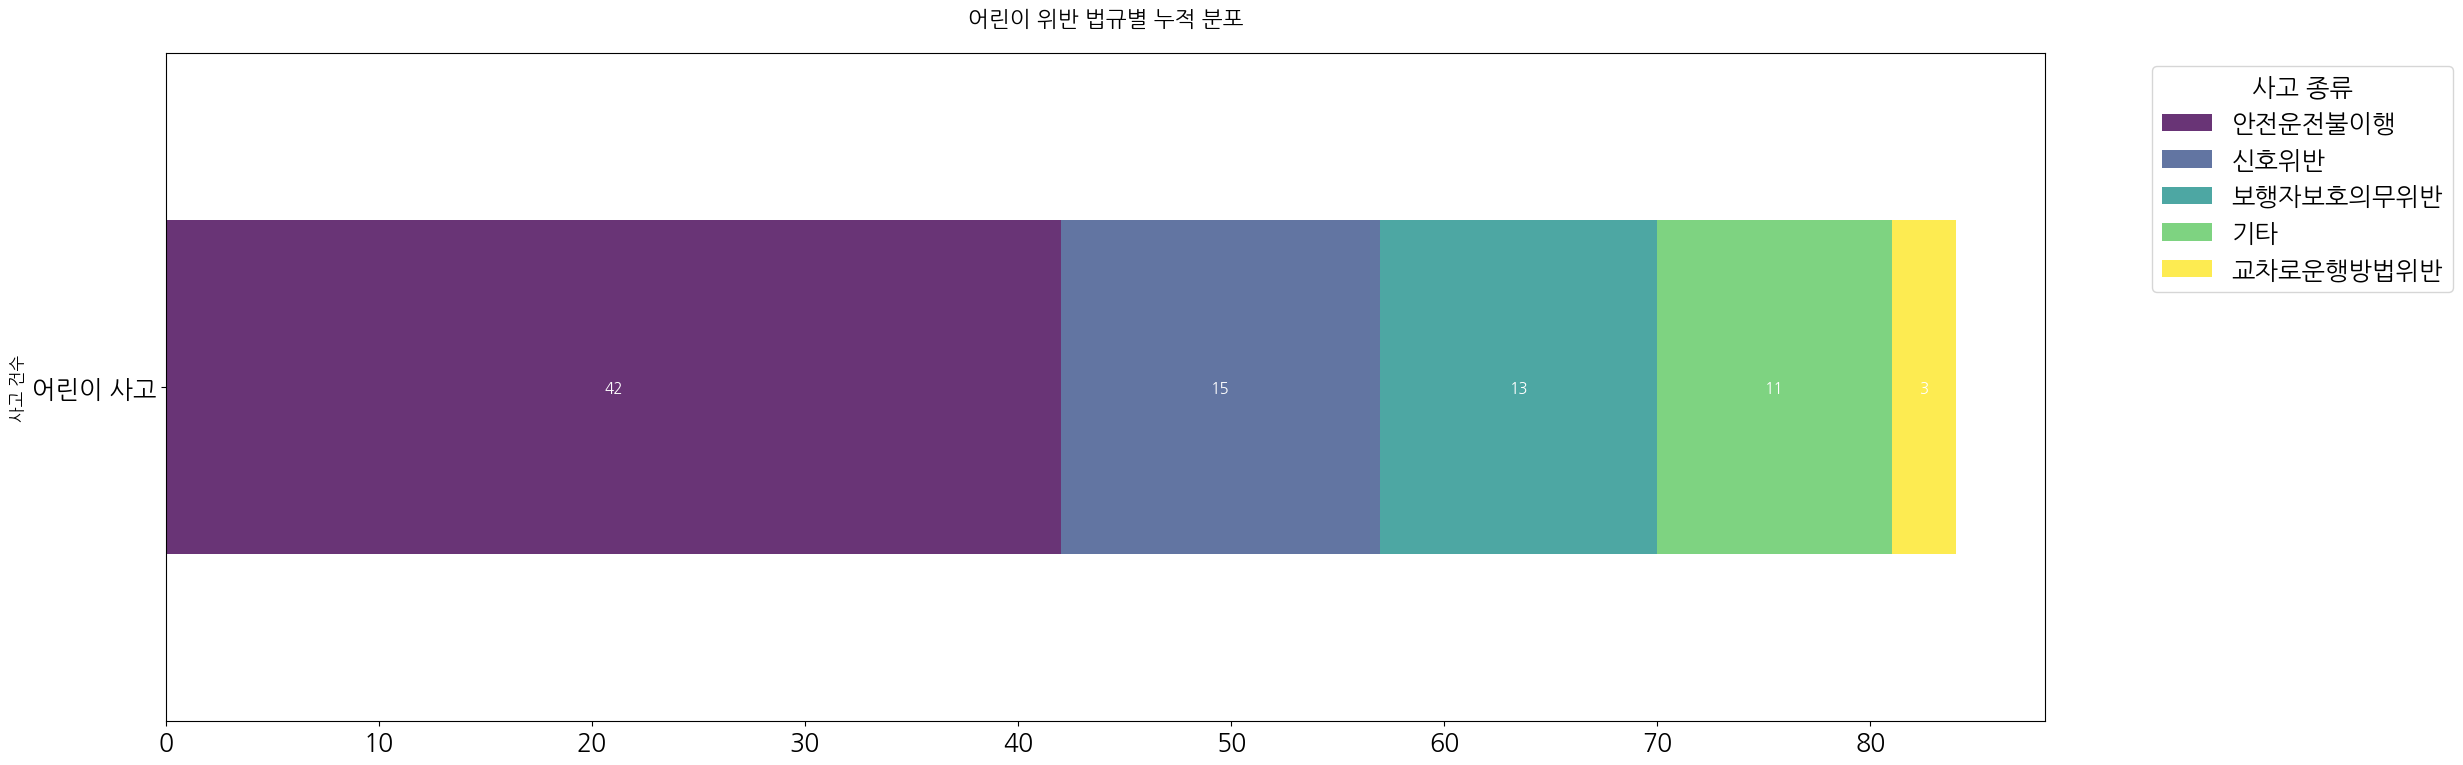

In [ ]:
plt.rc('font', family='NanumGothic')

acc_counts = dv_child['violation'].value_counts().to_frame().T
acc_counts.index = ['어린이 사고'] 

ax = acc_counts.plot(kind='barh', stacked=True, figsize=(25,8), 
                     colormap='viridis', alpha=0.8, width=0.5)

plt.title('어린이 위반 법규별 누적 분포', fontsize=16, pad=20)
plt.ylabel('사고 건수', fontsize=12)
plt.xticks(rotation=0) 

plt.legend(title='사고 종류', bbox_to_anchor=(1.05, 1), loc='upper left')

for p in ax.patches:
    width = p.get_width()   
    height = p.get_height()
    x, y = p.get_xy()       
    
    if width > 0:
        ax.text(x + width/2,        
                y + height/2,      
                f'{int(width)}',    
                ha='center', va='center', 
                fontsize=11, color='white', fontweight='bold')
plt.tight_layout()
plt.show()

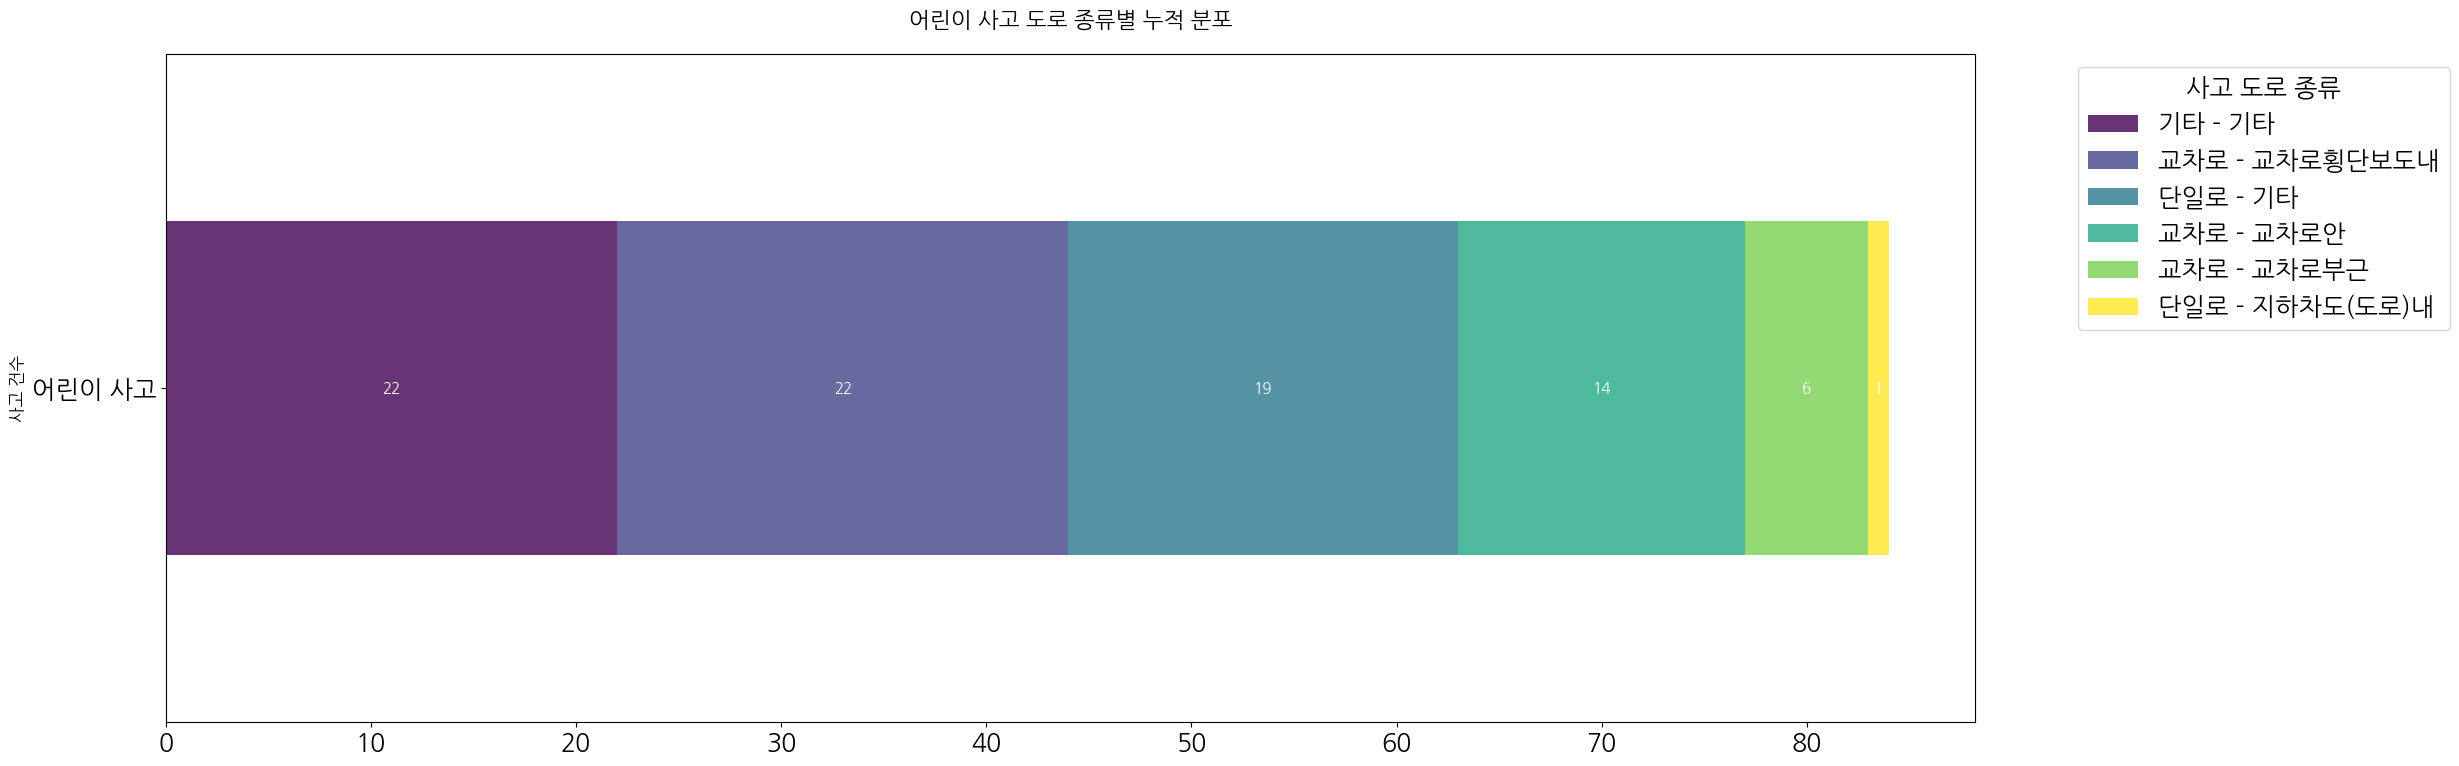

In [ ]:
plt.rc('font', family='NanumGothic')

acc_counts = dv_child['road_type'].value_counts().to_frame().T
acc_counts.index = ['어린이 사고'] 

ax = acc_counts.plot(kind='barh', stacked=True, figsize=(25,8), 
                     colormap='viridis', alpha=0.8, width=0.5)

plt.title('어린이 사고 도로 종류별 누적 분포', fontsize=16, pad=20)
plt.ylabel('사고 건수', fontsize=12)
plt.xticks(rotation=0) 

plt.legend(title='사고 도로 종류', bbox_to_anchor=(1.05, 1), loc='upper left')

for p in ax.patches:
    width = p.get_width()  
    height = p.get_height()
    x, y = p.get_xy()       
    
    if width > 0:
        ax.text(x + width/2,        
                y + height/2,        
                f'{int(width)}',   
                ha='center', va='center', 
                fontsize=11, color='white', fontweight='bold')
plt.tight_layout()
plt.show()

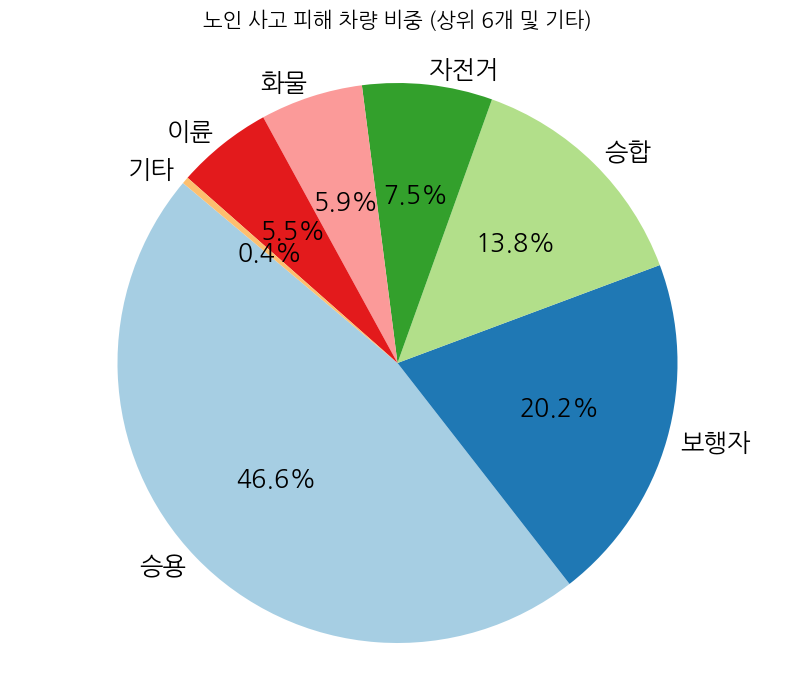

In [ ]:
data_counts = dv_old['victim_vhcle'].value_counts()

top6 = data_counts.head(6)
etc_sum = data_counts.iloc[6:].sum()

if etc_sum > 0:
    plot_data = top6.copy()
    plot_data['기타'] = etc_sum
else:
    plot_data = top6

plt.figure(figsize=(10, 8))
plt.pie(plot_data, 
        labels=plot_data.index, 
        autopct='%1.1f%%',      
        startangle=140,         
        labeldistance=1.05,
        colors=plt.cm.Paired.colors)

plt.title('노인 사고 피해 차량 비중 (상위 6개 및 기타)', fontsize=15, pad=20)
plt.axis('equal') 
plt.show()


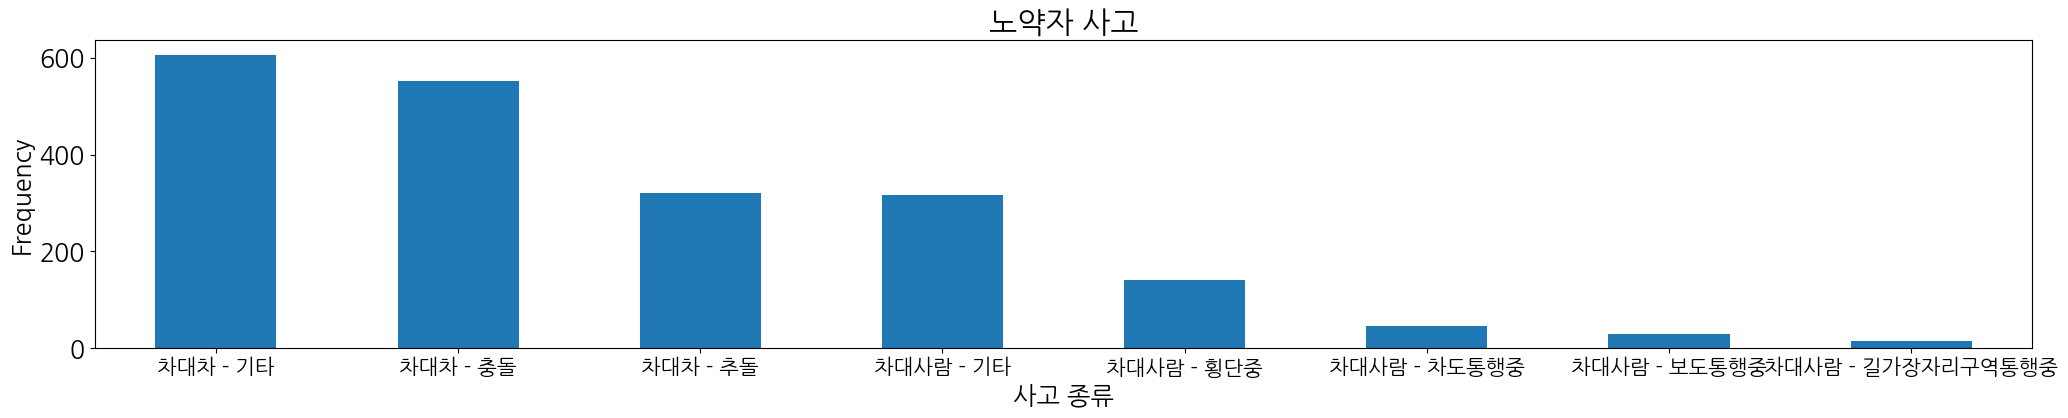

In [ ]:
plt.rc('font', family='NanumGothic') 

counts = dv_old['acc_type'].value_counts()
plt.figure(figsize=(25, 4))

counts.plot(kind='bar')
plt.xticks(fontsize=15)
plt.title('노약자 사고')
plt.xlabel('사고 종류')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
plt.show()

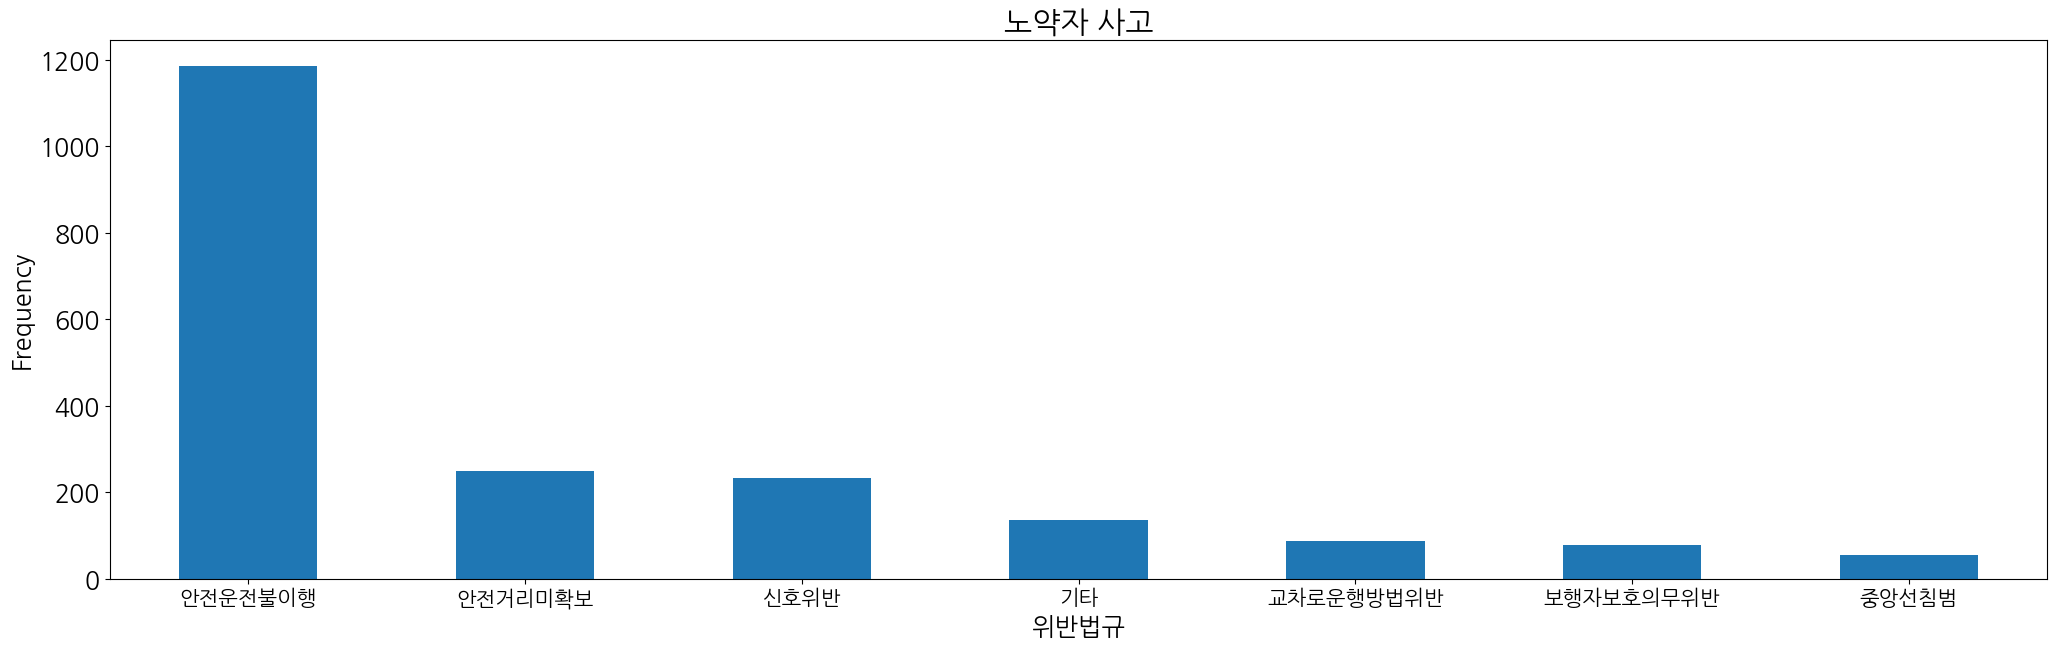

In [ ]:
plt.rc('font', family='NanumGothic') 

counts = dv_old['violation'].value_counts()
plt.figure(figsize=(25, 7))

counts.plot(kind='bar')
plt.xticks(fontsize=15)
plt.title('노약자 사고')
plt.xlabel('위반법규')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
plt.show()

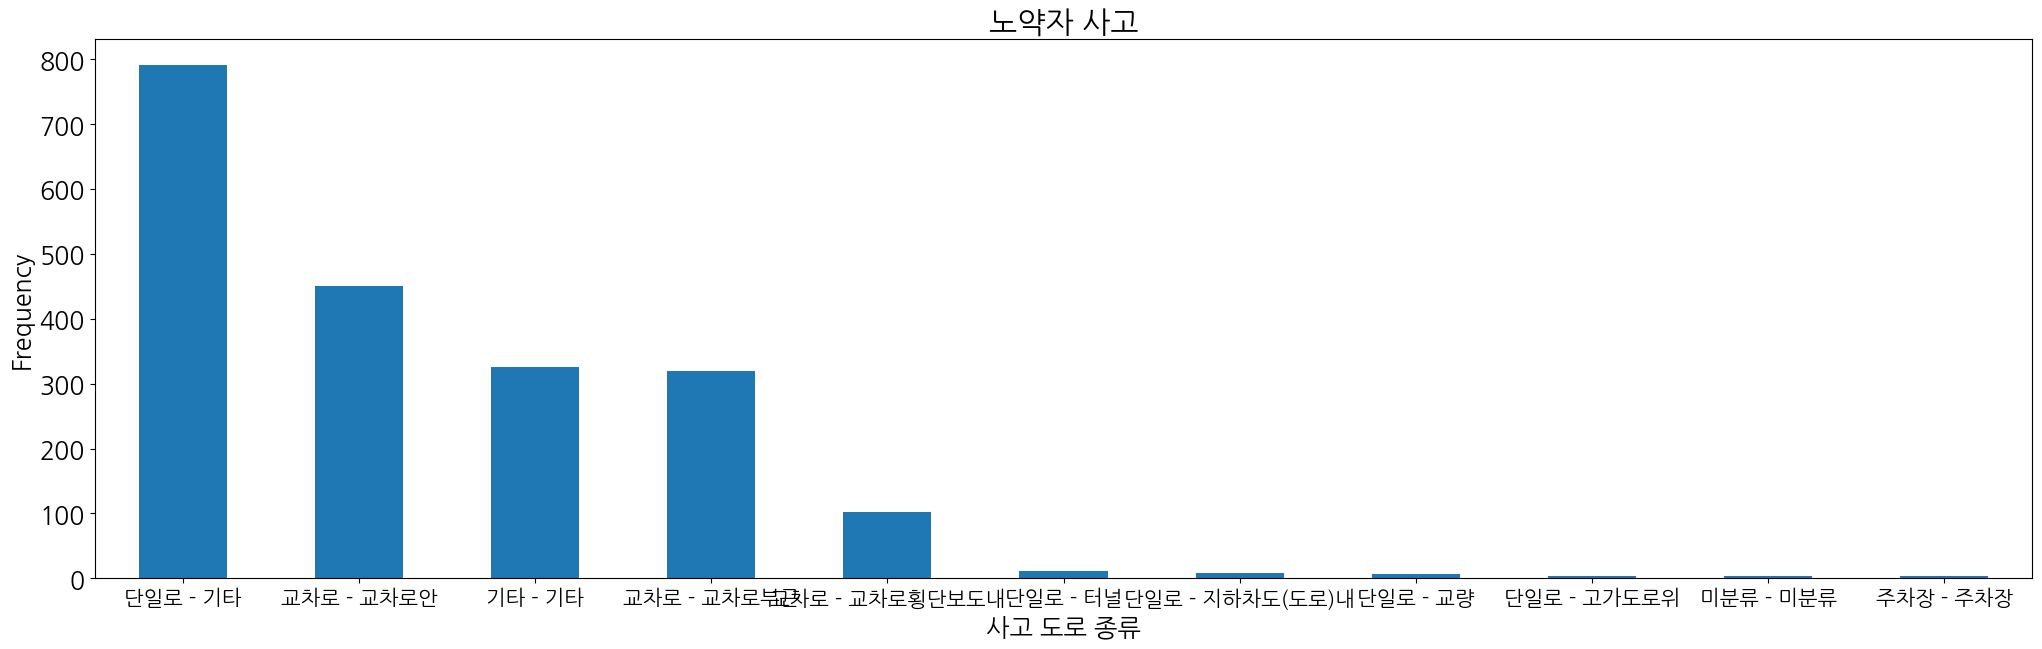

In [ ]:
plt.rc('font', family='NanumGothic') 

counts = dv_old['road_type'].value_counts()
plt.figure(figsize=(25, 7))

counts.plot(kind='bar')
plt.xticks(fontsize=15)
plt.title('노약자 사고')
plt.xlabel('사고 도로 종류')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
plt.show()

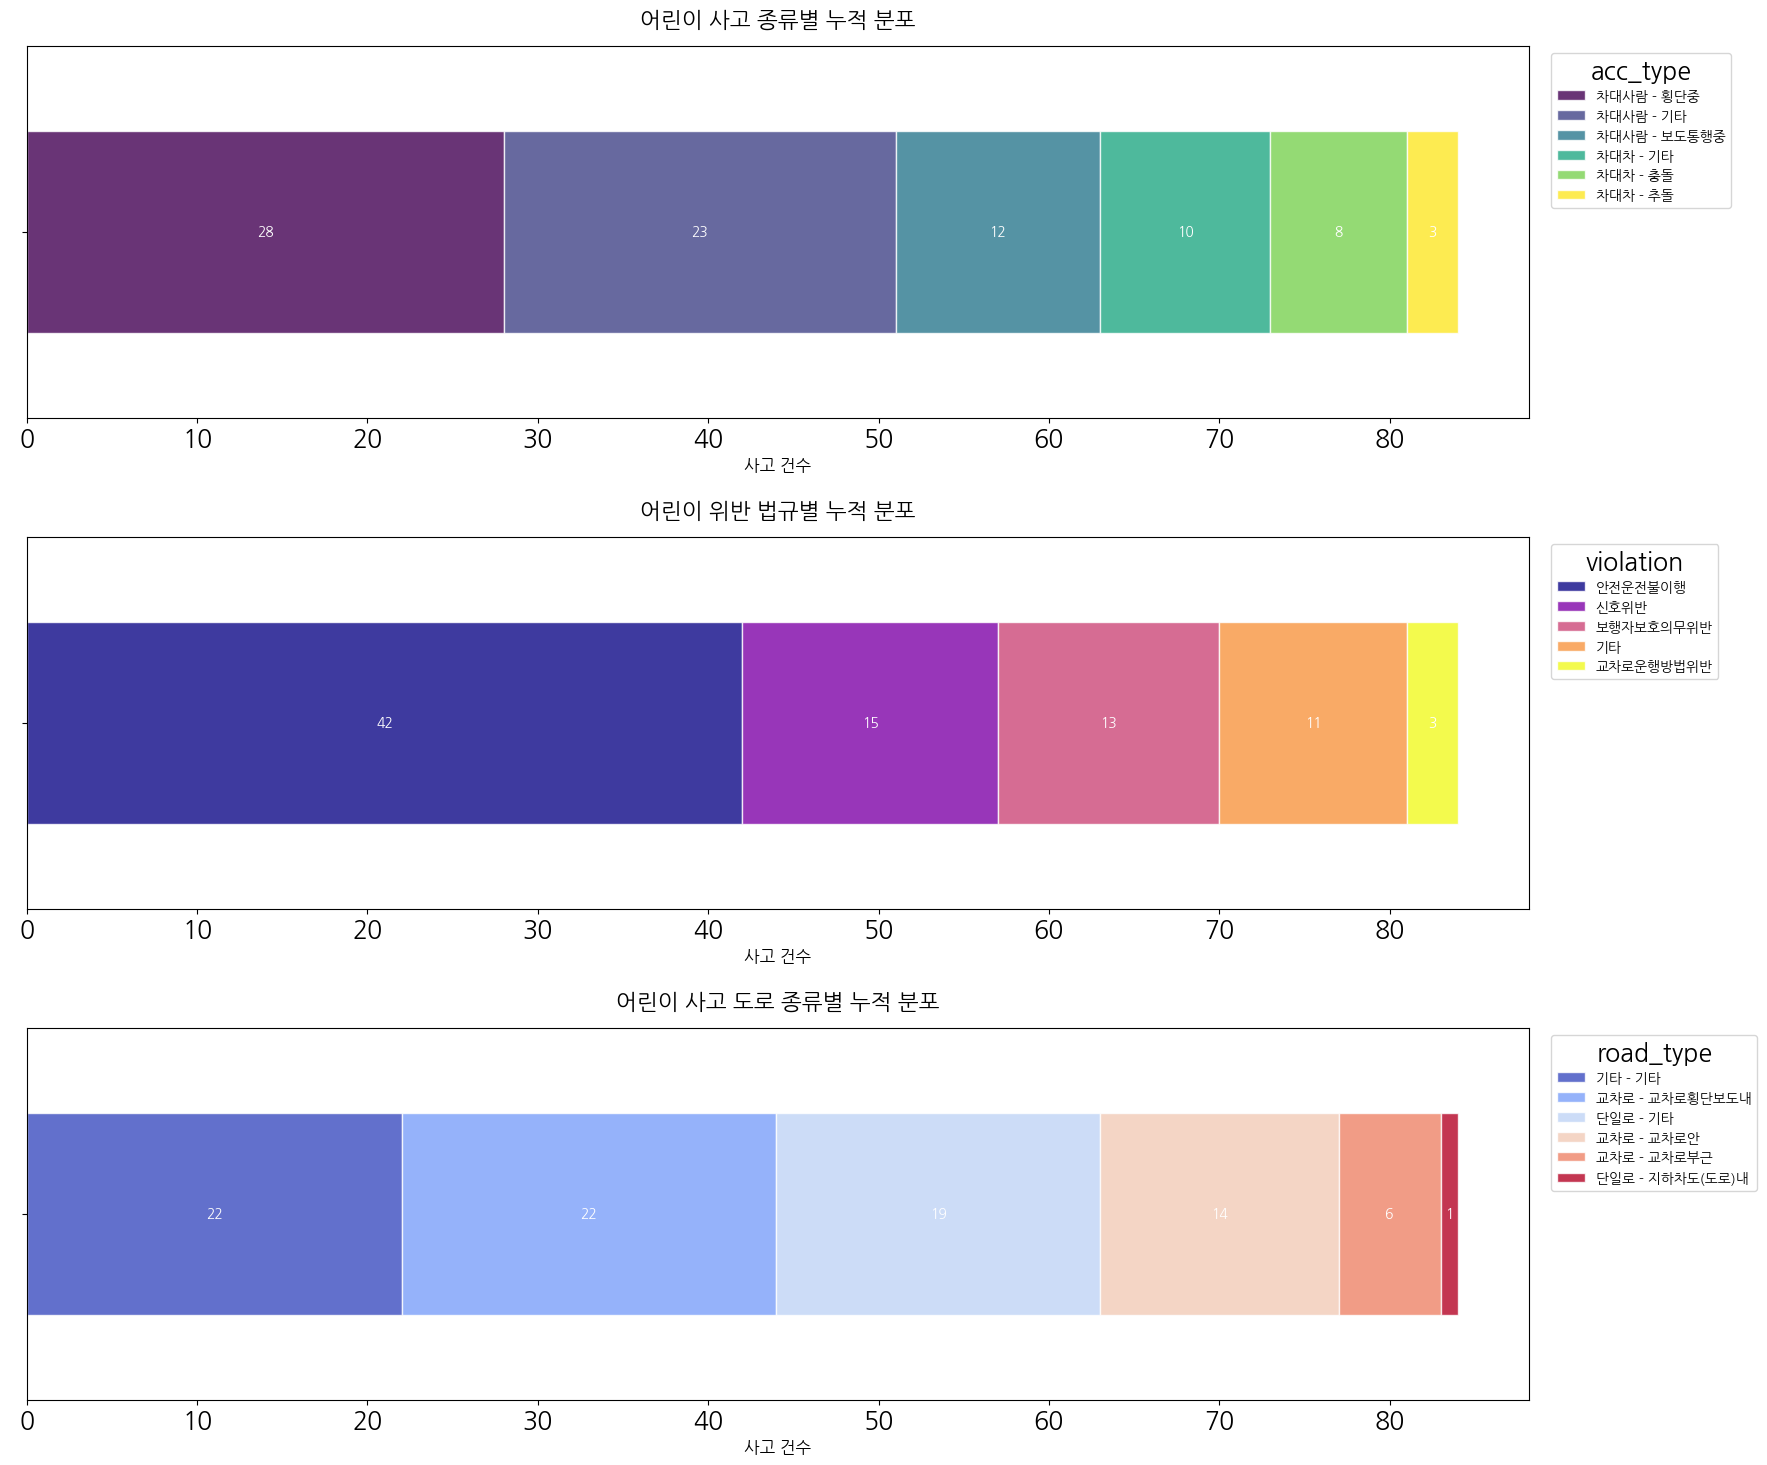

In [ ]:
plt.rc('font', family='NanumGothic')

columns = ['acc_type', 'violation', 'road_type']
titles = ['어린이 사고 종류별 누적 분포', '어린이 위반 법규별 누적 분포', '어린이 사고 도로 종류별 누적 분포']
cmaps = ['viridis', 'plasma', 'coolwarm']  

fig, axes = plt.subplots(3, 1, figsize=(18, 15))

for i, col in enumerate(columns):
    acc_counts = dv_child[col].value_counts().to_frame().T
    acc_counts.index = [' ']
    
    ax = acc_counts.plot(kind='barh', stacked=True, ax=axes[i], 
                         colormap=cmaps[i], alpha=0.8, width=0.6, edgecolor='white')

    axes[i].set_title(titles[i], fontsize=16, pad=15)
    axes[i].set_xlabel('사고 건수', fontsize=12)
    axes[i].set_ylabel('')
    
    axes[i].legend(title=col, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=10)

    for p in axes[i].patches:
        width = p.get_width()
        height = p.get_height()
        x, y = p.get_xy()
        
        if width > 0:
            axes[i].text(x + width/2, 
                         y + height/2, 
                         f'{int(width)}', 
                         ha='center', va='center', 
                         fontsize=10, color='white', fontweight='bold')

plt.tight_layout()
plt.show()


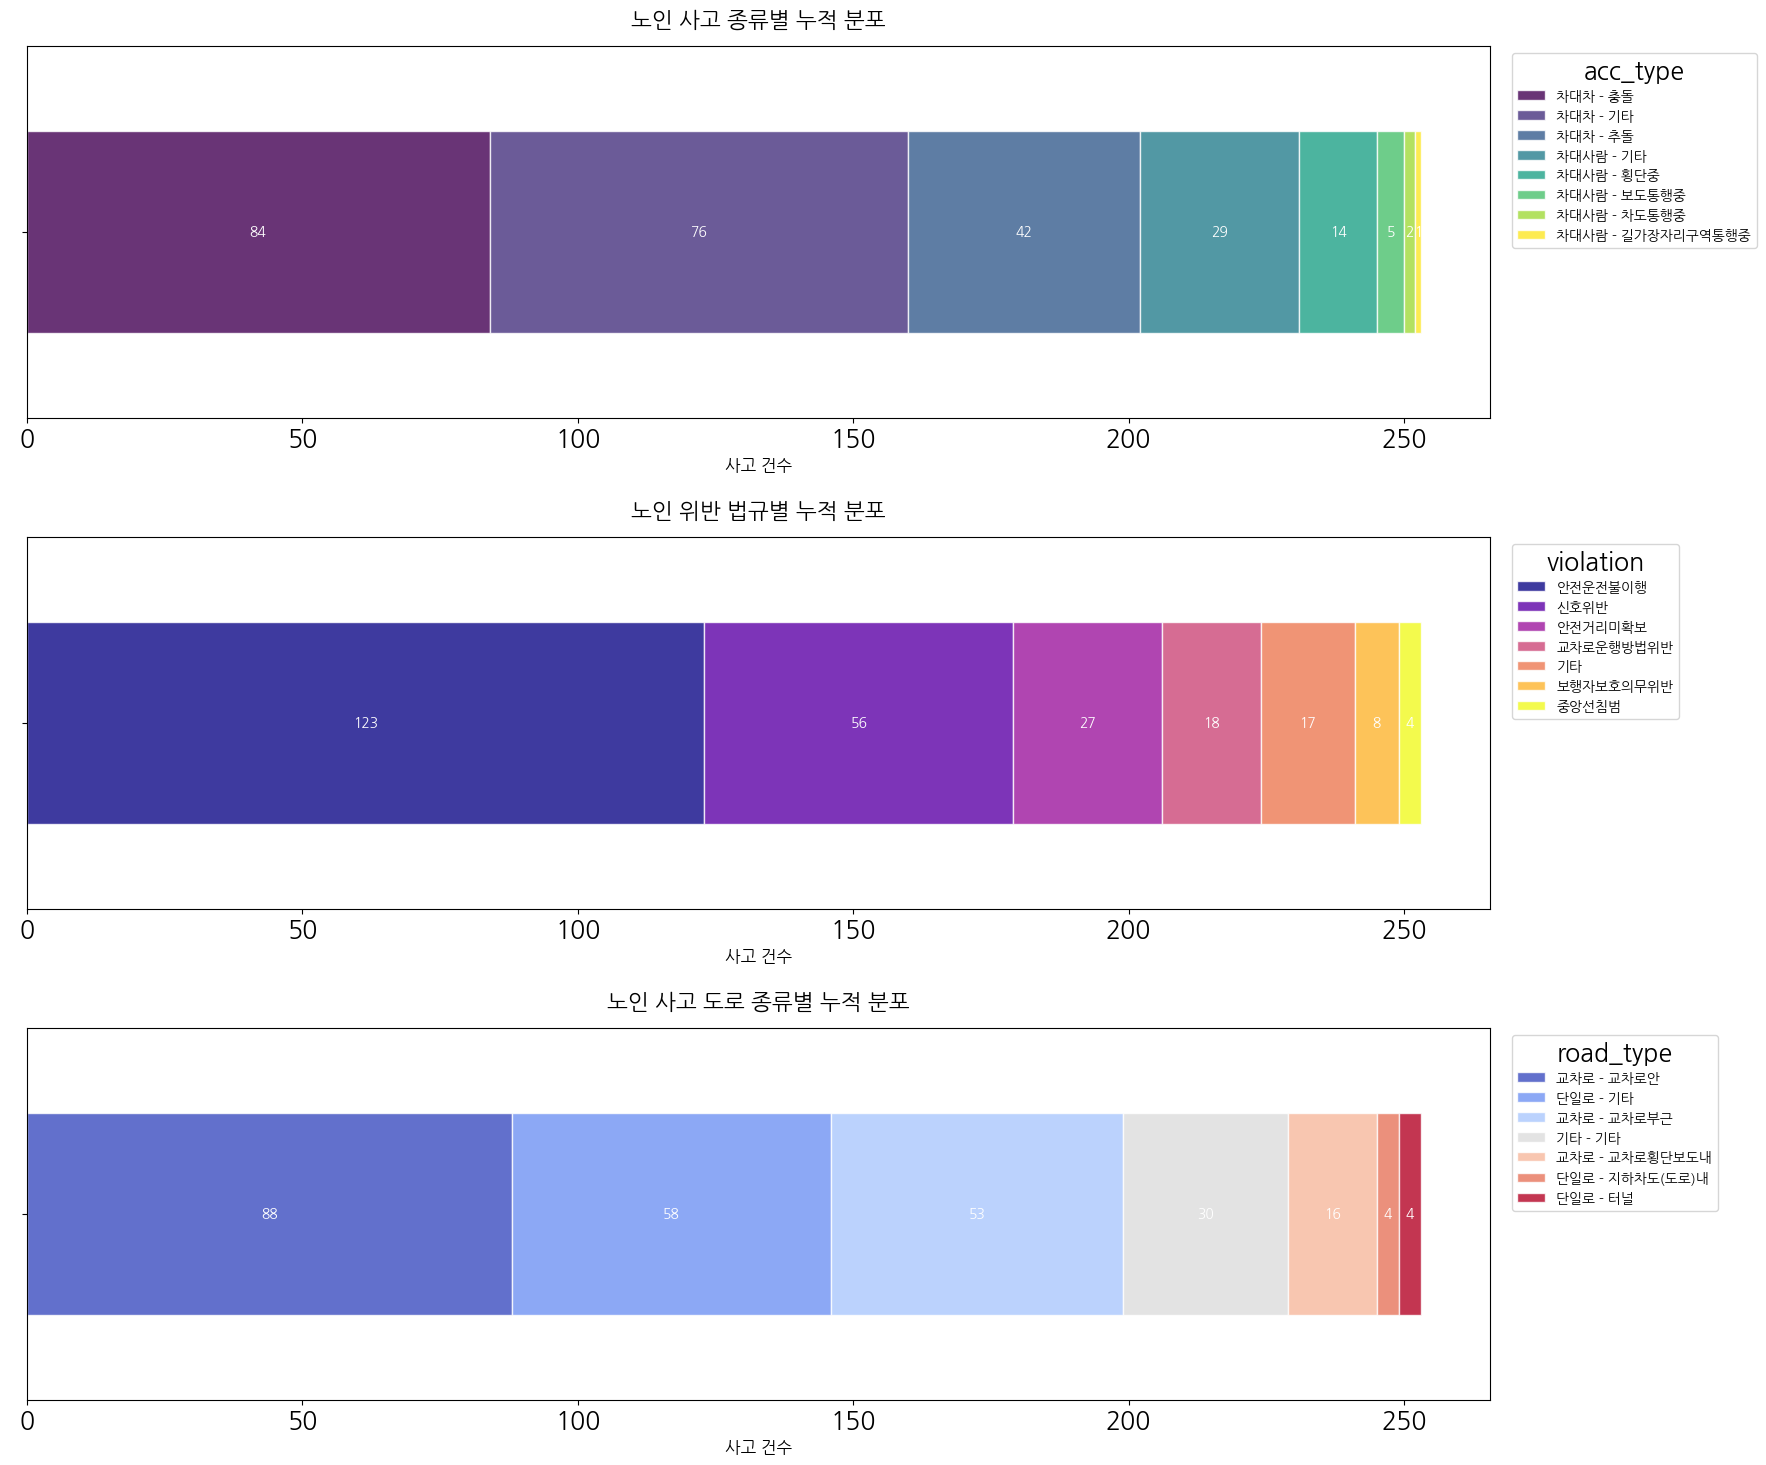

In [ ]:
plt.rc('font', family='NanumGothic')

columns = ['acc_type', 'violation', 'road_type']
titles = ['노인 사고 종류별 누적 분포', '노인 위반 법규별 누적 분포', '노인 사고 도로 종류별 누적 분포']
cmaps = ['viridis', 'plasma', 'coolwarm']  

fig, axes = plt.subplots(3, 1, figsize=(18, 15))

for i, col in enumerate(columns):
    acc_counts = dv_old[col].value_counts().to_frame().T
    acc_counts.index = [' ']
    ax = acc_counts.plot(kind='barh', stacked=True, ax=axes[i], 
                         colormap=cmaps[i], alpha=0.8, width=0.6, edgecolor='white')
    
    axes[i].set_title(titles[i], fontsize=16, pad=15)
    axes[i].set_xlabel('사고 건수', fontsize=12)
    axes[i].set_ylabel('') 
    
    axes[i].legend(title=col, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=10)
    
    for p in axes[i].patches:
        width = p.get_width()
        height = p.get_height()
        x, y = p.get_xy()
        
        if width > 0:
            axes[i].text(x + width/2, 
                         y + height/2, 
                         f'{int(width)}', 
                         ha='center', va='center', 
                         fontsize=10, color='white', fontweight='bold')

plt.tight_layout()
plt.show()


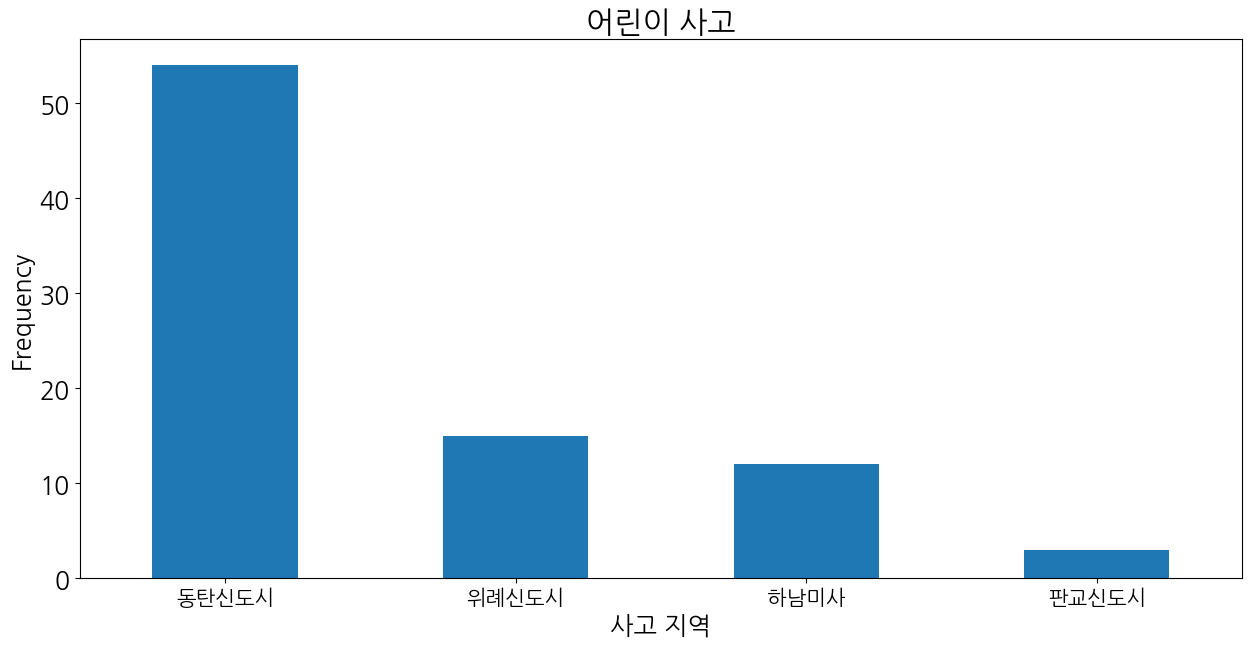

In [ ]:
plt.rc('font', family='NanumGothic') 

counts = dv_child['zoneName'].value_counts()
plt.figure(figsize=(15, 7))

counts.plot(kind='bar')
plt.xticks(fontsize=15)
plt.title('어린이 사고')
plt.xlabel('사고 지역')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
plt.show()

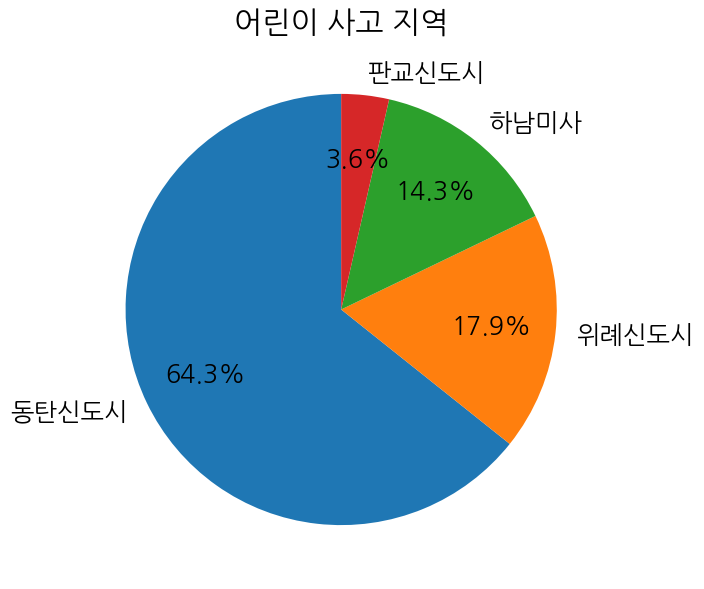

In [ ]:
plt.rc('font', family='NanumGothic') 

counts = dv_child['zoneName'].value_counts()
plt.figure(figsize=(25, 7))

counts.plot(kind='pie', 
            autopct='%.1f%%', 
            pctdistance=0.7,   
            startangle=90,    
            ylabel=''       
           )
plt.xticks(fontsize=15)
plt.title('어린이 사고 지역')
plt.xticks(rotation=0)
plt.show()

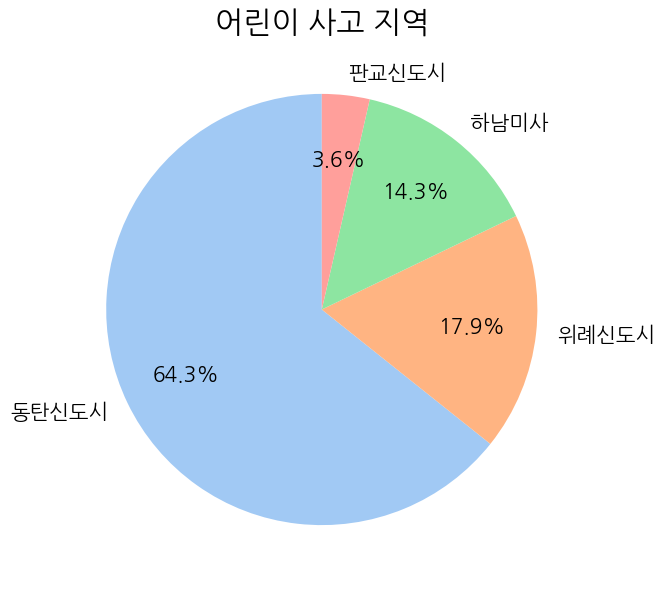

In [ ]:
plt.rc('font', family='NanumGothic') 

colors = sns.color_palette('pastel')[0:len(counts)]

counts = dv_child['zoneName'].value_counts()
plt.figure(figsize=(25, 7))

counts.plot(kind='pie',
            fontsize=15,
            colors=colors,
            autopct='%.1f%%', 
            pctdistance=0.7,  
            startangle=90,     
            ylabel=''         
           )
plt.xticks(fontsize=15)
plt.title('어린이 사고 지역')
plt.xticks(rotation=0)
plt.show()

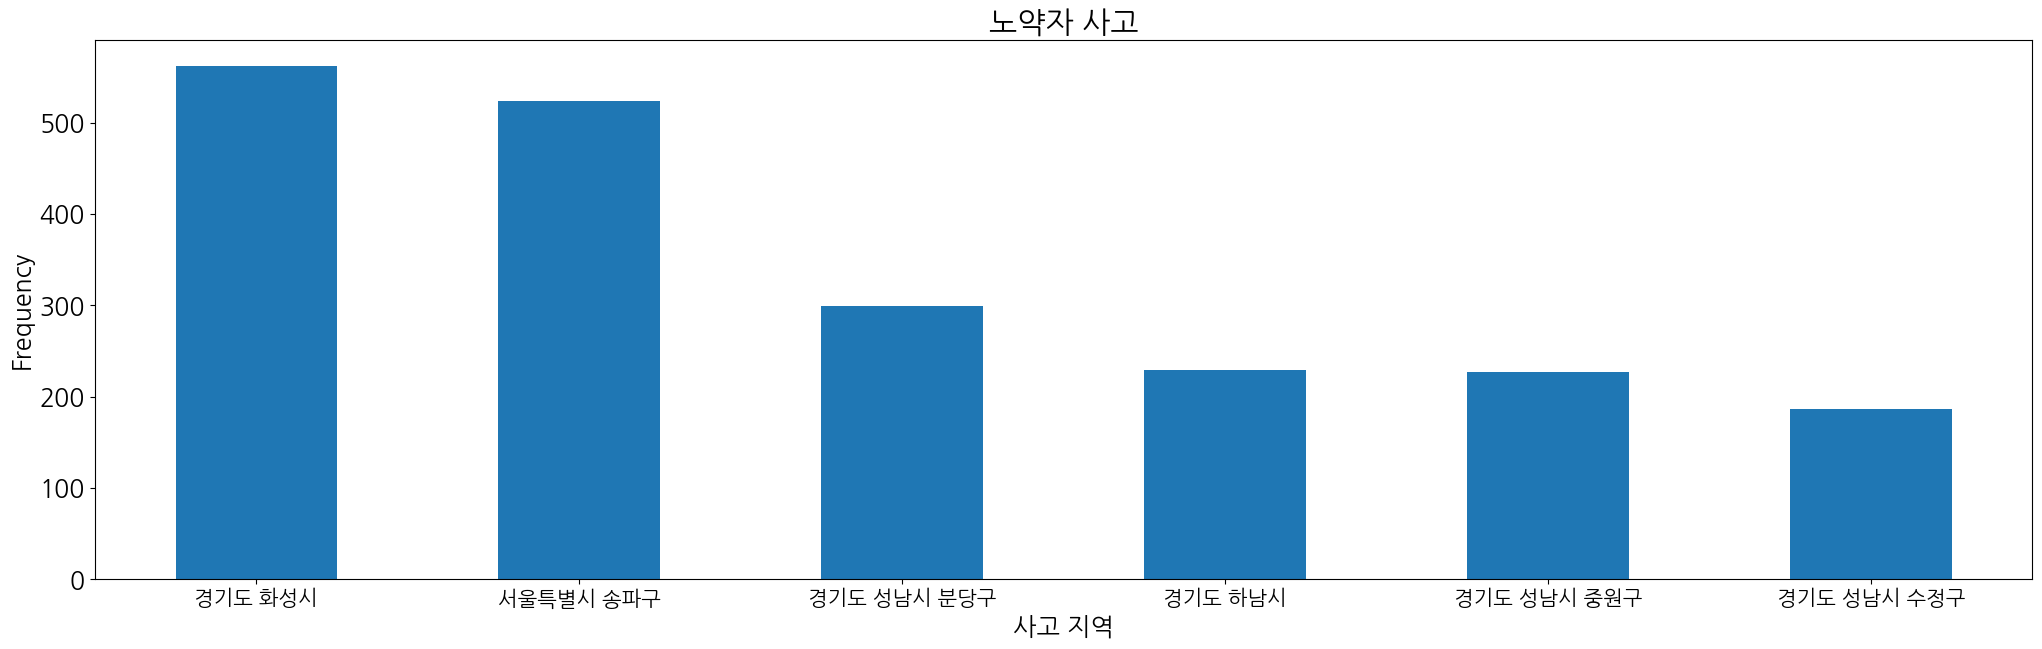

In [ ]:
plt.rc('font', family='NanumGothic') 

counts = dv_old['sgg'].value_counts()
plt.figure(figsize=(25, 7))

counts.plot(kind='bar')
plt.xticks(fontsize=15)
plt.title('노약자 사고')
plt.xlabel('사고 지역')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
plt.show()

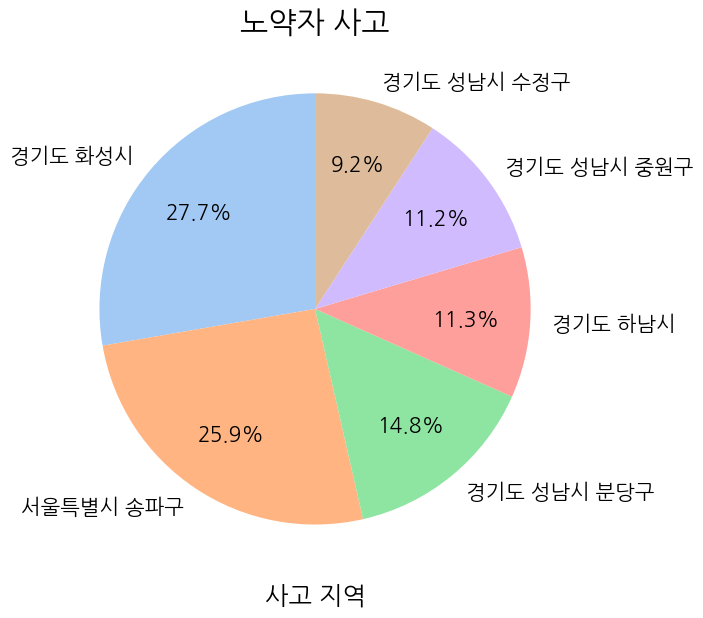

In [ ]:
plt.rc('font', family='NanumGothic') 

colors = sns.color_palette('pastel')[0:len(counts)]

counts = dv_old['sgg'].value_counts()
plt.figure(figsize=(25, 7))

counts.plot(kind='pie', 
            fontsize=15,
            colors=colors,
            autopct='%.1f%%', 
            pctdistance=0.7,  
            startangle=90,    
            ylabel=''         
           )
plt.xticks(fontsize=15)
plt.title('노약자 사고')
plt.xlabel('사고 지역')
plt.xticks(rotation=0)
plt.show()


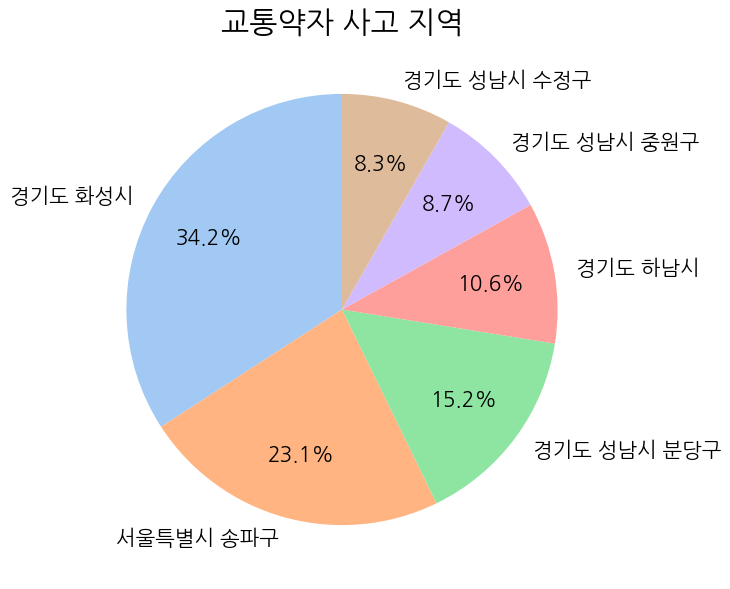

In [ ]:
plt.rc('font', family='NanumGothic') 

colors = sns.color_palette('pastel')[0:len(counts)]

counts = dv['sgg'].value_counts()
plt.figure(figsize=(25, 7))

counts.plot(kind='pie', 
            fontsize=15,
            colors=colors,
            autopct='%.1f%%', 
            pctdistance=0.7,   
            startangle=90,    
            ylabel=''         
           )
plt.xticks(fontsize=15)
plt.title('교통약자 사고 지역')
plt.xticks(rotation=0)
plt.show()


## 5) 격자 단위 사고 건수 집계

In [ ]:
dv = dv.to_crs("EPSG:4326")
grid = gpd.read_file("01._격자_(4개_시·구).geojson")
grid = grid.to_crs("EPSG:4326")

dv_grid = gpd.sjoin(dv, grid, how="left", predicate="within")
dv_count = dv_grid.groupby(["gid","age_group"]).size().reset_index(name="accident_cnt")
age_map = {
    '61-64세': 'old_pop',
    '65세 이상': 'old_pop',
    '12세 이하': 'child_pop'
}

dv_count['age_broad'] = dv_count['age_group'].map(age_map)

dv_final = dv_count.groupby(['gid', 'age_broad'])['accident_cnt'].sum().reset_index()
child_df = dv_final[dv_final['age_broad'] == 'child_pop']
old_df = dv_final[dv_final['age_broad'] == 'old_pop']

child_geo = grid.merge(child_df, on='gid')
old_geo = grid.merge(old_df, on='gid')


## 6) 어린이 사고 히트맵

In [ ]:
# 사고발생지역: 어린이

# 1. 격자의 중심점(centroid) 좌표 추출
child_geo['lat'] = child_geo.geometry.centroid.y
child_geo['lng'] = child_geo.geometry.centroid.x

# 2. 지도 중심 설정 (추출한 lat, lng의 평균값 사용)
m_child = folium.Map(location=[child_geo['lat'].mean(), child_geo['lng'].mean()], zoom_start=12,tiles="CartoDB positron")

# 3. 히트맵 데이터 생성 [위도, 경도, 가중치(사고횟수)]
heat_child = [[row['lat'], row['lng'], row['accident_cnt']] for idx, row in child_geo.iterrows()]

HeatMap(heat_child, radius=15, blur=20).add_to(m_child)

m_child


/tmp/ipykernel_102/1822755326.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  child_geo['lat'] = child_geo.geometry.centroid.y
/tmp/ipykernel_102/1822755326.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  child_geo['lng'] = child_geo.geometry.centroid.x


## 7) 노인 사고 히트맵

In [ ]:
# 사고발생지역: 노인
old_geo['lat'] = old_geo.geometry.centroid.y
old_geo['lng'] = old_geo.geometry.centroid.x

# 2. 지도 중심 설정 (추출한 lat, lng의 평균값 사용)
m_old = folium.Map(location=[old_geo['lat'].mean(), old_geo['lng'].mean()], zoom_start=12,tiles="CartoDB positron")

# 3. 히트맵 데이터 생성 [위도, 경도, 가중치(사고횟수)]
heat_old = [[row['lat'], row['lng'], row['accident_cnt']] for idx, row in old_geo.iterrows()]

HeatMap(heat_old, radius=15, blur=20).add_to(m_old)

m_old

/tmp/ipykernel_102/2570467543.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  old_geo['lat'] = old_geo.geometry.centroid.y
/tmp/ipykernel_102/2570467543.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  old_geo['lng'] = old_geo.geometry.centroid.x


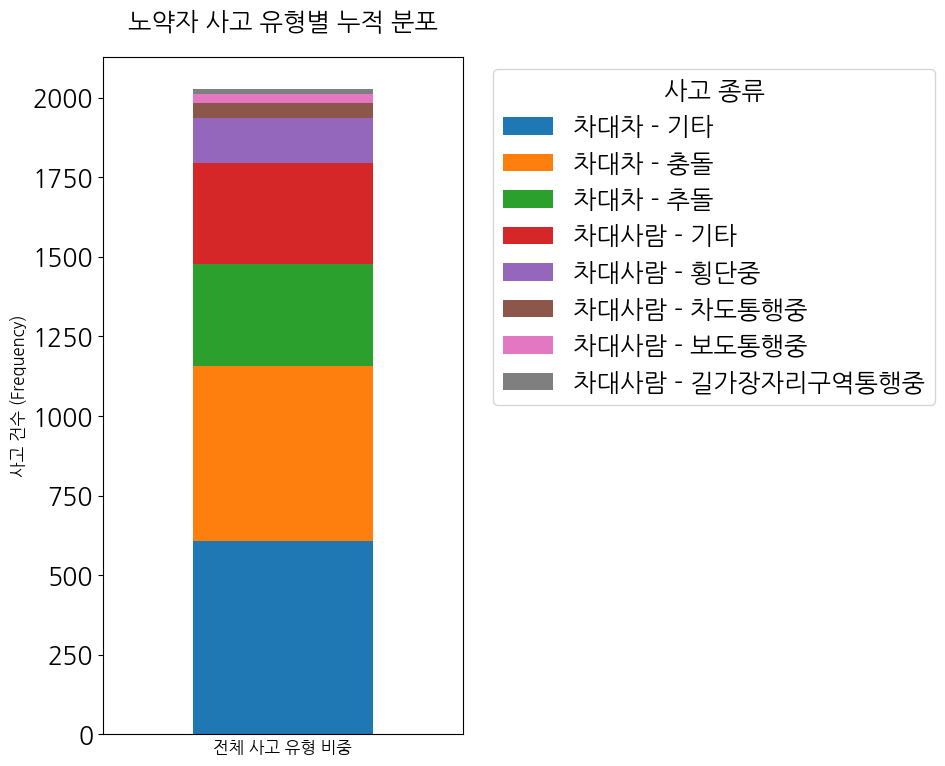

In [ ]:
plt.rc('font', family='NanumGothic') 

counts = dv_old['acc_type'].value_counts()
df_stacked = pd.DataFrame([counts.values], columns=counts.index)

plt.figure(figsize=(10, 8)) 
df_stacked.plot(kind='bar', stacked=True, ax=plt.gca(), width=0.5)

plt.title('노약자 사고 유형별 누적 분포', fontsize=18, pad=20)
plt.ylabel('사고 건수 (Frequency)', fontsize=12)
plt.xlabel('전체 사고 유형 비중', fontsize=12)

plt.xticks([]) 

plt.legend(title='사고 종류', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


## 8) 사고 유형 비중 비교

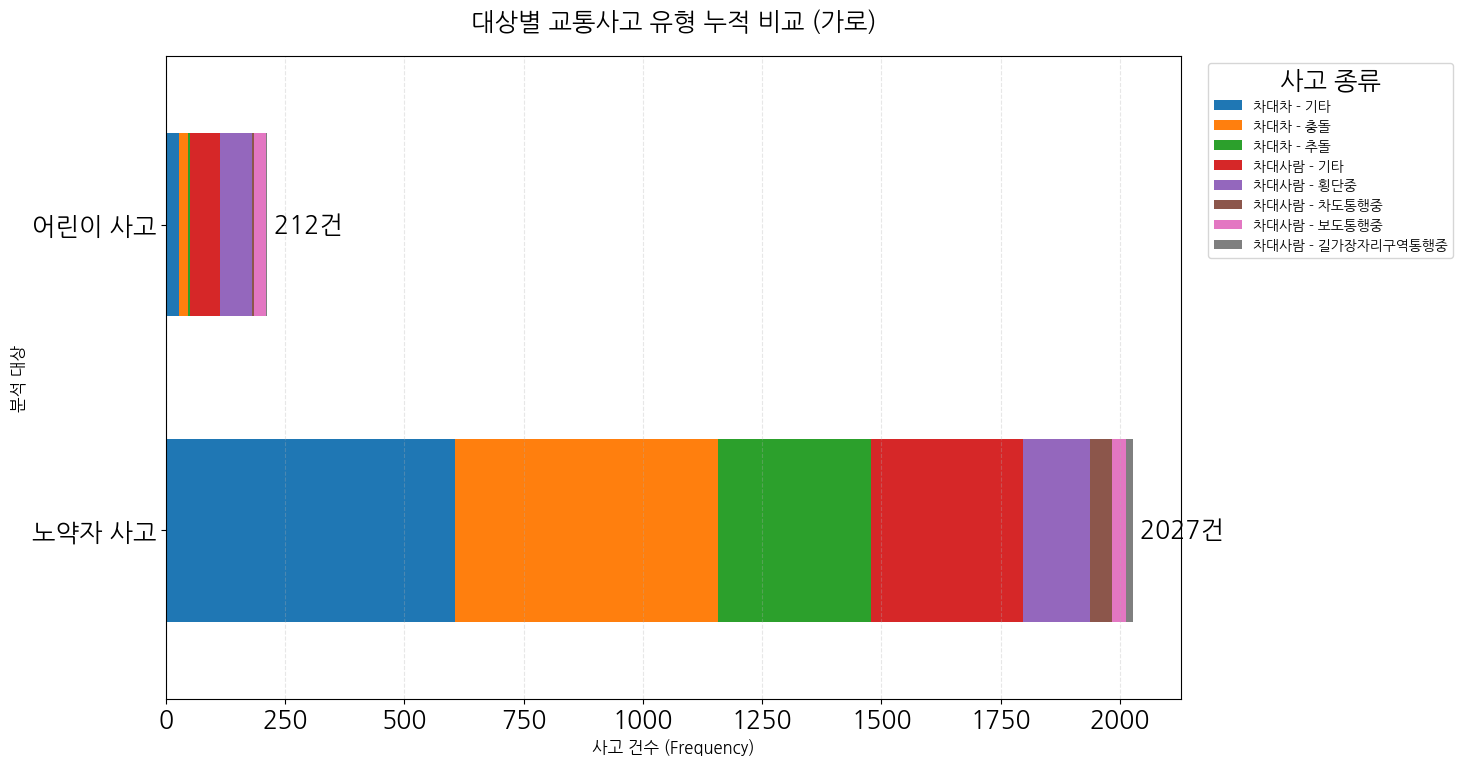

In [ ]:
# 1. 데이터 집계 및 병합 (노약자 vs 어린이)
old_counts = dv_old['acc_type'].value_counts()
child_counts = dv_child['acc_type'].value_counts()

df_combined = pd.DataFrame([old_counts, child_counts], index=['노약자 사고', '어린이 사고'])

plt.rc('font', family='NanumGothic')
fig, ax = plt.subplots(figsize=(15, 8))

df_combined.plot(kind='barh', stacked=True, ax=ax, width=0.6)

plt.title('대상별 교통사고 유형 누적 비교 (가로)', fontsize=18, pad=20)
plt.xlabel('사고 건수 (Frequency)', fontsize=12)
plt.ylabel('분석 대상', fontsize=12)

plt.legend(title='사고 종류', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)

for i, total in enumerate(df_combined.sum(axis=1)):
    ax.text(total + 0.5, i, f' {int(total)}건', va='center', fontweight='bold')

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

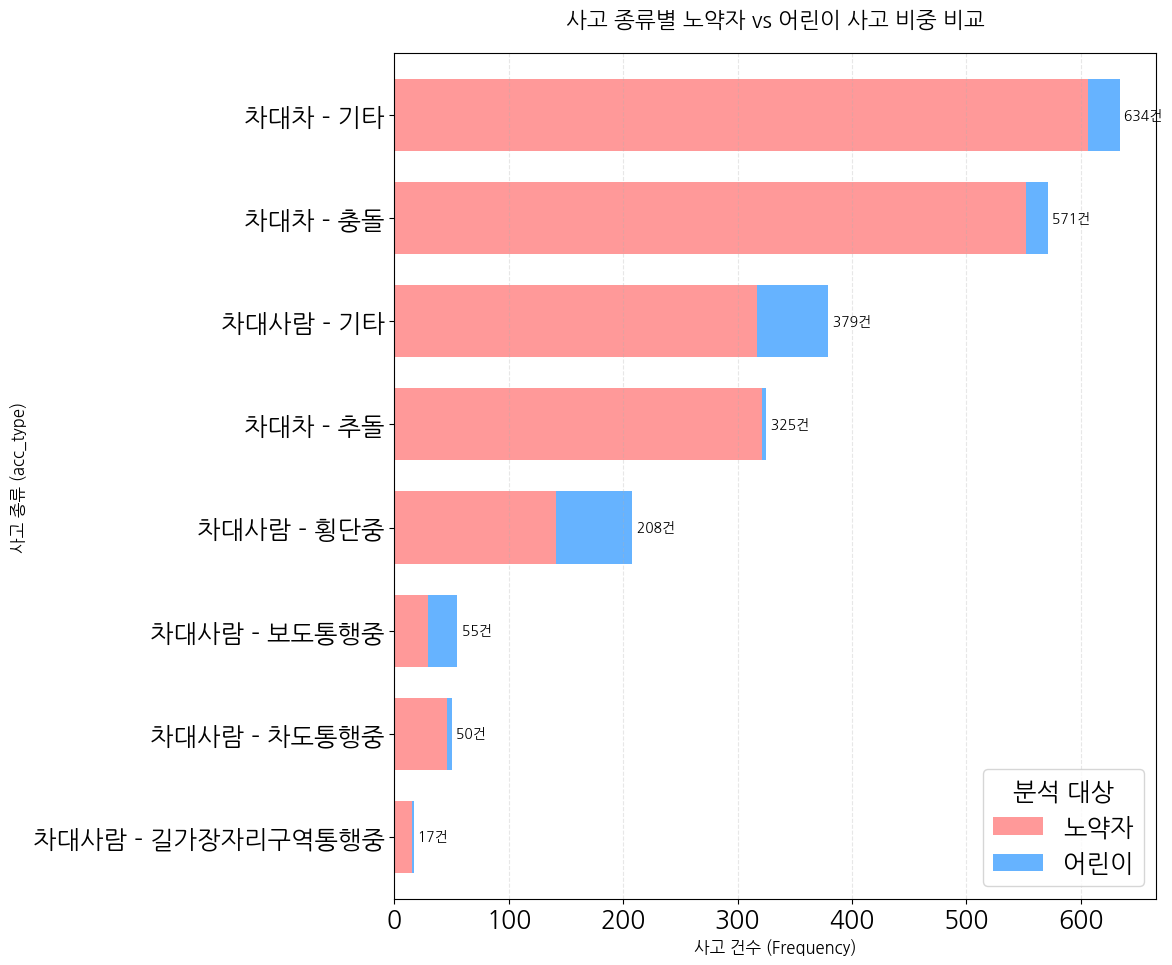

In [ ]:
old_counts = dv_old['acc_type'].value_counts()
child_counts = dv_child['acc_type'].value_counts()

df_by_type = pd.DataFrame({'노약자': old_counts, '어린이': child_counts}).fillna(0)

df_by_type['total'] = df_by_type['노약자'] + df_by_type['어린이']
df_by_type = df_by_type.sort_values('total', ascending=True) 
df_by_type = df_by_type.drop(columns='total')

plt.rc('font', family='NanumGothic')
fig, ax = plt.subplots(figsize=(12, 10))

df_by_type.plot(kind='barh', stacked=True, ax=ax, color=['#ff9999', '#66b3ff'], width=0.7)

plt.title('사고 종류별 노약자 vs 어린이 사고 비중 비교', fontsize=16, pad=20)
plt.xlabel('사고 건수 (Frequency)', fontsize=12)
plt.ylabel('사고 종류 (acc_type)', fontsize=12)

for i, (old, child) in enumerate(zip(df_by_type['노약자'], df_by_type['어린이'])):
    total = old + child
    ax.text(total + 0.5, i, f' {int(total)}건', va='center', fontsize=10)

plt.legend(title='분석 대상', loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


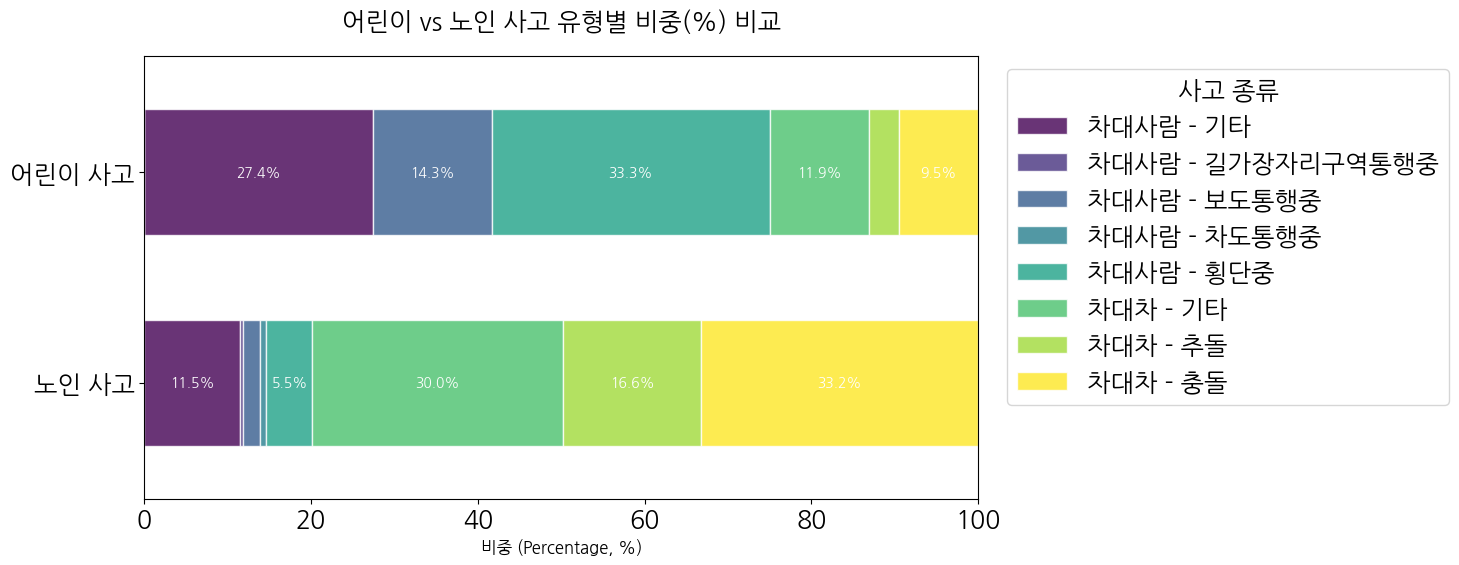

In [ ]:
plt.rc('font', family='NanumGothic')

child_counts = dv_child['acc_type'].value_counts()
old_counts = dv_old['acc_type'].value_counts()

combined_df = pd.DataFrame({'노인 사고': old_counts, '어린이 사고': child_counts}).T.fillna(0)
combined_pct = combined_df.div(combined_df.sum(axis=1), axis=0) * 100
ax = combined_pct.plot(kind='barh', stacked=True, figsize=(15, 6), 
                        colormap='viridis', alpha=0.8, width=0.6, edgecolor='white')

plt.title('어린이 vs 노인 사고 유형별 비중(%) 비교', fontsize=18, pad=20)
plt.xlabel('비중 (Percentage, %)', fontsize=12)
plt.xlim(0, 100) 
plt.legend(title='사고 종류', bbox_to_anchor=(1.02, 1), loc='upper left')

for p in ax.patches:
    width = p.get_width()  
    height = p.get_height()
    x, y = p.get_xy()
    
    if width > 5: 
        ax.text(x + width/2, 
                y + height/2, 
                f'{width:.1f}%', 
                ha='center', va='center', 
                fontsize=10, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

## 9) 위반 법규 비중 비교

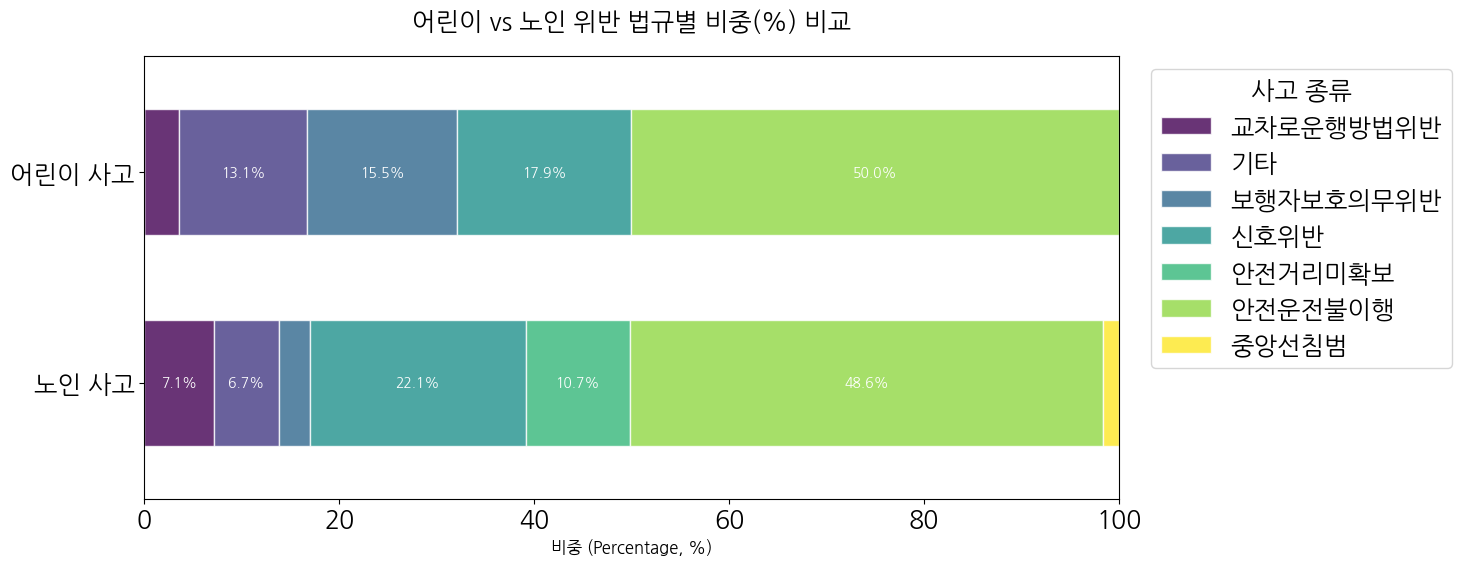

In [ ]:
plt.rc('font', family='NanumGothic')

child_counts = dv_child['violation'].value_counts()
old_counts = dv_old['violation'].value_counts()

combined_df = pd.DataFrame({'노인 사고': old_counts, '어린이 사고': child_counts}).T.fillna(0)
combined_pct = combined_df.div(combined_df.sum(axis=1), axis=0) * 100

ax = combined_pct.plot(kind='barh', stacked=True, figsize=(15, 6), 
                        colormap='viridis', alpha=0.8, width=0.6, edgecolor='white')

plt.title('어린이 vs 노인 위반 법규별 비중(%) 비교', fontsize=18, pad=20)
plt.xlabel('비중 (Percentage, %)', fontsize=12)
plt.xlim(0, 100) 
plt.legend(title='사고 종류', bbox_to_anchor=(1.02, 1), loc='upper left')

for p in ax.patches:
    width = p.get_width()   
    height = p.get_height()
    x, y = p.get_xy()
    
    if width > 5: 
        ax.text(x + width/2, 
                y + height/2, 
                f'{width:.1f}%', 
                ha='center', va='center', 
                fontsize=10, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

## 10) 도로 형태 비중 비교

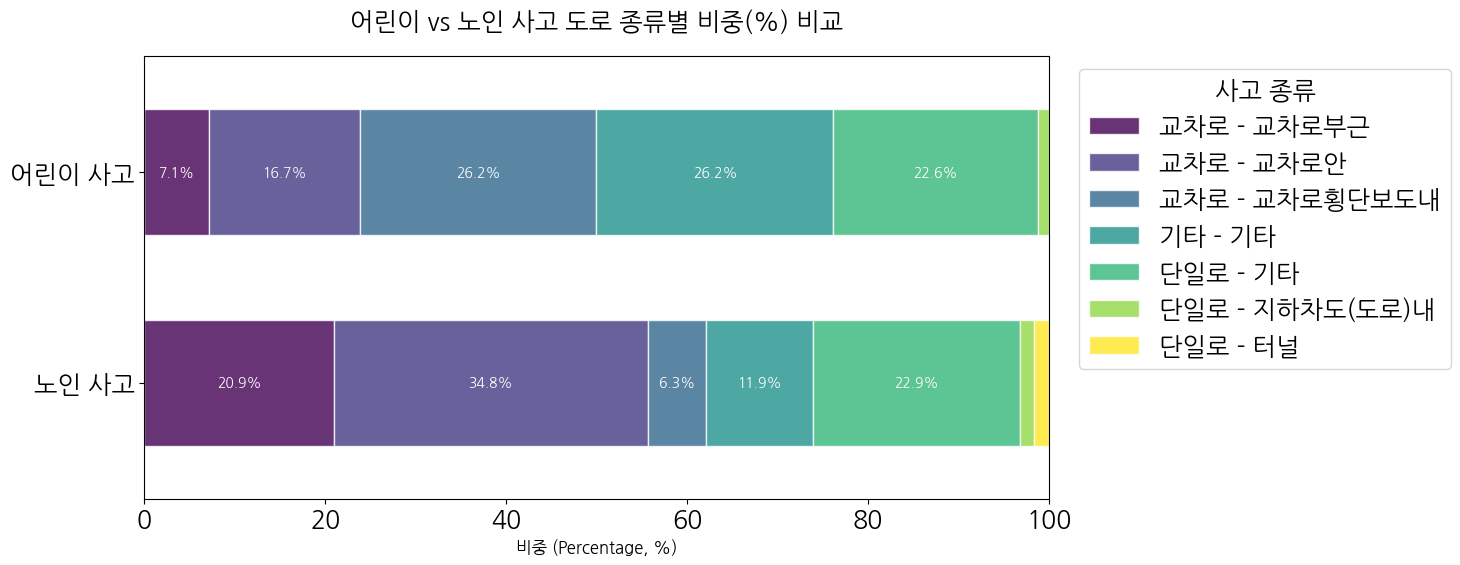

In [ ]:
plt.rc('font', family='NanumGothic')

child_counts = dv_child['road_type'].value_counts()
old_counts = dv_old['road_type'].value_counts()

combined_df = pd.DataFrame({'노인 사고': old_counts, '어린이 사고': child_counts}).T.fillna(0)
combined_pct = combined_df.div(combined_df.sum(axis=1), axis=0) * 100
ax = combined_pct.plot(kind='barh', stacked=True, figsize=(15, 6), 
                        colormap='viridis', alpha=0.8, width=0.6, edgecolor='white')

plt.title('어린이 vs 노인 사고 도로 종류별 비중(%) 비교', fontsize=18, pad=20)
plt.xlabel('비중 (Percentage, %)', fontsize=12)
plt.xlim(0, 100) 
plt.legend(title='사고 종류', bbox_to_anchor=(1.02, 1), loc='upper left')

for p in ax.patches:
    width = p.get_width()   
    height = p.get_height()
    x, y = p.get_xy()
    
    if width > 5:
        ax.text(x + width/2, 
                y + height/2, 
                f'{width:.1f}%', 
                ha='center', va='center', 
                fontsize=10, color='white', fontweight='bold')

plt.tight_layout()
plt.show()